# ***`Plant Disease Classifier Project`***

## Setup: Environment & Data

Runs on Google Colab with a T4 GPU. Expects the preprocessed dataset package produced locally (`plant_insight_data.zip`: class-grouped images, `manifest_split.csv` with the leak-safe 70/15/15 split, and the `configs/` folder) already uploaded to `Google Drive/PlantInsight/`. The cells below mount Drive and extract that package before training.

In [1]:
from google.colab import drive; drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q '/content/drive/MyDrive/PlantInsight/plant_insight_data.zip' -d /content/plant_data

In [3]:
!ls /content/plant_data

color  configs	manifest_split.csv


In [4]:
import os
import json
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
import matplotlib.pyplot as plt

DATA_DIR = "/content/plant_data"
CONFIG_DIR = f"{DATA_DIR}/configs"

with open(f"{CONFIG_DIR}/preprocessing.json") as f:
    prep_config = json.load(f)
with open(f"{CONFIG_DIR}/class_weights.json") as f:
    class_weights_dict = json.load(f)
with open(f"{CONFIG_DIR}/class_mapping.json") as f:
    class_mapping = json.load(f)

target_classes = sorted(list(set(class_mapping.values())))
class_to_idx = {cls: idx for idx, cls in enumerate(target_classes)}
class_weights = {class_to_idx[k]: v for k, v in class_weights_dict.items()}

print(f"Total target classes: {len(target_classes)}")


Total target classes: 34


In [5]:
df = pd.read_csv(f"{DATA_DIR}/manifest_split.csv")

# Adapt paths to the unzipped Colab hierarchy
df['rel_path'] = df['rel_path'].str.replace('raw/color/', 'color/')
df['full_path'] = df['rel_path'].apply(lambda p: os.path.join(DATA_DIR, p))

df['target_class'] = df['class_name'].map(class_mapping)
df['class_idx'] = df['target_class'].map(class_to_idx)

sample_path = df.iloc[0]['full_path']
assert os.path.exists(sample_path), f"ERROR: File not found -> {sample_path}"
print("File paths verified successfully.")


File paths verified successfully.


In [6]:
IMG_SIZE = (prep_config['input_height'], prep_config['input_width'])
BATCH_SIZE = 32

def parse_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=prep_config['channels'])

    if prep_config['resize_method'] == 'bilinear':
        img = tf.image.resize(img, IMG_SIZE, method='bilinear')

    return img, label

def create_dataset(split_name, shuffle=False):
    split_df = df[df['final_split'] == split_name]
    paths = split_df['full_path'].values
    labels = split_df['class_idx'].values

    labels = tf.keras.utils.to_categorical(labels, num_classes=len(target_classes))

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)

    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset('train', shuffle=True)
val_ds = create_dataset('val', shuffle=False)
test_ds = create_dataset('test', shuffle=False)
print("Datasets created successfully.")


Datasets created successfully.


## MobileNetV3Small Baseline

First candidate: MobileNetV3Small with a frozen, ImageNet-pretrained backbone, training only the classification head. This is the mobile-friendly baseline that EfficientNetB0 is compared against.

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.042),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

base_model = applications.MobileNetV3Small(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(target_classes), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │        19,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,738 (3.66 MB)

 Trainable params: 19,618 (76.63 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [8]:
checkpoint_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stop_cb = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, early_stop_cb]
)


Starting training...
Epoch 1/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9314 - loss: 0.2515
Epoch 1: val_loss improved from None to 0.20853, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 58s 48ms/step - accuracy: 0.9338 - loss: 0.2403 - val_accuracy: 0.9389 - val_loss: 0.2085
Epoch 2/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9374 - loss: 0.2164
Epoch 2: val_loss improved from 0.20853 to 0.18671, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9389 - loss: 0.2140 - val_accuracy: 0.9395 - val_loss: 0.1867
Epoch 3/15
1185/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9433 - loss: 0.

Evaluating BASELINE MobileNetV3Small on test set...

259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step

🏆 BASELINE MODEL METRICS
{
  "top1_accuracy": 0.949,
  "top3_accuracy": 0.9947,
  "precision_weighted": 0.9519,
  "recall_weighted": 0.949,
  "f1_weighted": 0.9493
}

📊 Training Graph (1-12 Epochs):


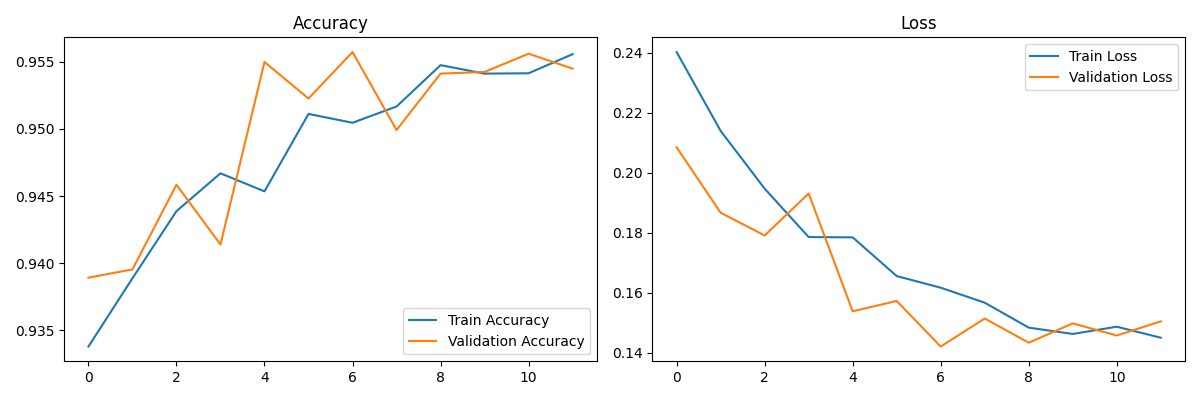

In [9]:
import json
import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score
from IPython.display import Image, display

model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras")

print("Evaluating BASELINE MobileNetV3Small on test set...\n")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds, verbose=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "recall_weighted": round(float(recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "f1_weighted": round(float(f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4)
}

metrics_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("\n🏆 BASELINE MODEL METRICS")
print(json.dumps(metrics, indent=2))

print("\n📊 Training Graph (1-12 Epochs):")
display(Image(filename="/content/drive/MyDrive/PlantInsight/training_graph.png", width=1000))


In [10]:
checkpoint_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
model = tf.keras.models.load_model(checkpoint_path)
print("Model loaded from checkpoint.")

Model loaded from checkpoint.


In [11]:
print("Evaluating on test set...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

precision = precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
recall = recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)

precision_macro = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
recall_macro = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision), 4),
    "recall_weighted": round(float(recall), 4),
    "f1_weighted": round(float(f1), 4),
    "precision_macro": round(float(precision_macro), 4),
    "recall_macro": round(float(recall_macro), 4),
    "f1_macro": round(float(f1_macro), 4),
}

metrics_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

Evaluating on test set...
259/259 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step
{
  "top1_accuracy": 0.949,
  "top3_accuracy": 0.9947,
  "precision_weighted": 0.9519,
  "recall_weighted": 0.949,
  "f1_weighted": 0.9493,
  "precision_macro": 0.9288,
  "recall_macro": 0.9445,
  "f1_macro": 0.9343
}


## EfficientNetB0 Baseline

**Architecture substitution note:** the plan called for EfficientNet-Lite0, which is purpose-built for mobile/TFLite quantization. Two independent Keras 3-compatible implementations were tried and both failed with the same root cause (`keras.utils.layer_utils` was removed in Keras 3). EfficientNetB0 is substituted instead, documented here rather than swapped silently. Risk to track: EfficientNetB0's swish activations and squeeze-and-excite blocks may not quantize as cleanly as Lite0 would have.

In [12]:
# Keras 3 native EfficientNetB0 (no external package, no version downgrade needed)
import time
from tensorflow.keras import layers, models, applications

base_model = applications.EfficientNetB0(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
    # No include_preprocessing arg here; the backbone rescales raw [0,255] input internally.
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(target_classes), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 34)             │        43,554 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,093,125 (15.61 MB)

 Trainable params: 43,554 (170.13 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
checkpoint_path = "/content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stop_cb = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Starting training EfficientNetB0...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, early_stop_cb]
)


Starting training EfficientNetB0...
Epoch 1/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7362 - loss: 1.3102
Epoch 1: val_loss improved from None to 0.31114, saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 143s 107ms/step - accuracy: 0.8514 - loss: 0.7451 - val_accuracy: 0.9207 - val_loss: 0.3111
Epoch 2/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9239 - loss: 0.3138
Epoch 2: val_loss improved from 0.31114 to 0.20531, saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 119s 100ms/step - accuracy: 0.9313 - loss: 0.2849 - val_accuracy: 0.9441 - val_loss: 0.2053
Epoch 3/15
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9465

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import os
import numpy as np
import tensorflow as tf
import pandas as pd

# Reload explicitly from disk rather than trusting the in-memory object left
# over from model.fit() -- this is what fixes the Keras 3 stale-state issue.
checkpoint_path = "/content/drive/MyDrive/PlantInsight/efficientnetb0_baseline.keras"
model = tf.keras.models.load_model(checkpoint_path)

print("Evaluating EfficientNetB0 on test set...")
y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "recall_weighted": round(float(recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "f1_weighted": round(float(f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
}

print("Benchmarking CPU inference speed...")
dummy_input = tf.random.uniform((1, 224, 224, 3))
for _ in range(10):  # warm-up
    model(dummy_input, training=False)

start_time = time.time()
for _ in range(100):
    model(dummy_input, training=False)
end_time = time.time()
inference_time_ms = ((end_time - start_time) / 100) * 1000
metrics["inference_time_ms"] = round(inference_time_ms, 2)

model_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
metrics["model_size_mb"] = round(model_size_mb, 2)

metrics_path = "/content/drive/MyDrive/PlantInsight/efficientnetb0_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("\n--- EfficientNetB0 Metrics ---")
print(json.dumps(metrics, indent=2))

print("\nGenerating model_comparison.csv...")
with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_metrics = json.load(f)

mb_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
mb_size_mb = os.path.getsize(mb_path) / (1024 * 1024) if os.path.exists(mb_path) else "N/A"

comparison_df = pd.DataFrame([
    {
        "Model": "MobileNetV3Small",
        "Top-1 Acc": mb_metrics["top1_accuracy"],
        "F1-Macro": mb_metrics["f1_macro"],
        "Model Size (MB)": round(mb_size_mb, 2) if isinstance(mb_size_mb, float) else mb_size_mb,
        "Inference (ms)": mb_metrics.get("inference_time_ms", "N/A (Skipped in Day3)")
    },
    {
        "Model": "EfficientNetB0",
        "Top-1 Acc": metrics["top1_accuracy"],
        "F1-Macro": metrics["f1_macro"],
        "Model Size (MB)": metrics["model_size_mb"],
        "Inference (ms)": metrics["inference_time_ms"]
    }
])

comparison_csv = "/content/drive/MyDrive/PlantInsight/model_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

print(f"\nSaved comparison to: {comparison_csv}")
print("\n--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))


Evaluating EfficientNetB0 on test set...
259/259 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step
Benchmarking CPU Inference Speed...

--- EfficientNetB0 Metrics ---
{
  "top1_accuracy": 0.9657,
  "top3_accuracy": 0.9966,
  "precision_weighted": 0.9676,
  "recall_weighted": 0.9657,
  "f1_weighted": 0.9659,
  "precision_macro": 0.9606,
  "recall_macro": 0.9578,
  "f1_macro": 0.9583,
  "inference_time_ms": 322.21,
  "model_size_mb": 16.77
}

Generating model_comparison.csv...

Saved comparison to: /content/drive/MyDrive/PlantInsight/model_comparison.csv

--- Final Model Comparison ---
           Model  Top-1 Acc  F1-Macro  Model Size (MB)  Inference (ms)
MobileNetV3Small     0.9490    0.9343             4.36          175.16
  EfficientNetB0     0.9657    0.9583            16.77          322.21


In [15]:
import time

mobilenet_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
mobilenet_model = tf.keras.models.load_model(mobilenet_path)

dummy_input = tf.random.uniform((1, 224, 224, 3))
for _ in range(10):
    mobilenet_model(dummy_input, training=False)

start_time = time.time()
for _ in range(100):
    mobilenet_model(dummy_input, training=False)
end_time = time.time()
mobilenet_inference_ms = ((end_time - start_time) / 100) * 1000

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_metrics = json.load(f)

mb_metrics["inference_time_ms"] = round(mobilenet_inference_ms, 2)
mb_metrics["model_size_mb"] = round(os.path.getsize(mobilenet_path) / (1024 * 1024), 2)

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json", "w") as f:
    json.dump(mb_metrics, f, indent=2)

print(json.dumps(mb_metrics, indent=2))

{
  "top1_accuracy": 0.949,
  "top3_accuracy": 0.9947,
  "precision_weighted": 0.9519,
  "recall_weighted": 0.949,
  "f1_weighted": 0.9493,
  "precision_macro": 0.9288,
  "recall_macro": 0.9445,
  "f1_macro": 0.9343,
  "inference_time_ms": 158.17,
  "model_size_mb": 4.36
}


In [16]:
import json
import os
import pandas as pd

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_metrics = json.load(f)

with open("/content/drive/MyDrive/PlantInsight/efficientnetb0_metrics.json") as f:
    eff_metrics = json.load(f)

comparison_df = pd.DataFrame([
    {
        "Model": "MobileNetV3Small",
        "Top-1 Acc": mb_metrics["top1_accuracy"],
        "F1-Macro": mb_metrics["f1_macro"],
        "Model Size (MB)": mb_metrics["model_size_mb"],
        "Inference (ms)": mb_metrics["inference_time_ms"],
    },
    {
        "Model": "EfficientNetB0",
        "Top-1 Acc": eff_metrics["top1_accuracy"],
        "F1-Macro": eff_metrics["f1_macro"],
        "Model Size (MB)": eff_metrics["model_size_mb"],
        "Inference (ms)": eff_metrics["inference_time_ms"],
    },
])

comparison_csv = "/content/drive/MyDrive/PlantInsight/model_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False)

print(f"Saved comparison to: {comparison_csv}")
print("\n--- Final Model Comparison ---")
print(comparison_df.to_string(index=False))

Saved comparison to: /content/drive/MyDrive/PlantInsight/model_comparison.csv

--- Final Model Comparison ---
           Model  Top-1 Acc  F1-Macro  Model Size (MB)  Inference (ms)
MobileNetV3Small     0.9490    0.9343             4.36          175.16
  EfficientNetB0     0.9657    0.9583            16.77          322.21


## Final Model Selection & Fine-Tuning

**Selection rationale:** EfficientNetB0 scores higher on raw accuracy (96.57% vs 94.90% Top-1) and F1-macro (0.9583 vs 0.9343), but MobileNetV3Small is ~3.8x smaller (4.36MB vs 16.77MB) and faster (175ms vs 322ms, same CPU benchmark). Since the final deliverable is an on-device mobile app, MobileNetV3Small is selected and fine-tuned below to close part of the accuracy gap.

### Inspecting the Backbone

Before fine-tuning, the backbone's internal layer structure is inspected directly rather than guessed, to decide exactly which blocks to unfreeze and to correctly locate BatchNormalization layers. BN layers are deliberately kept frozen during fine-tuning, following standard guidance for small or class-imbalanced batches.

In [17]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_baseline.keras"
)

for layer in model.layers:
    print(layer.name, "-", layer.__class__.__name__)

input_layer_1 - InputLayer
data_augmentation - Sequential
MobileNetV3Small - Functional
global_average_pooling2d - GlobalAveragePooling2D
dropout - Dropout
dense - Dense


In [18]:
backbone = model.get_layer("MobileNetV3Small")
print("Total layers in backbone:", len(backbone.layers))

print("\nLast 25 layers:")
for layer in backbone.layers[-25:]:
    print(layer.name, "-", layer.__class__.__name__)

Total layers in backbone: 157

Last 25 layers:
expanded_conv_9_squeeze_excite_relu - ReLU
expanded_conv_9_squeeze_excite_conv_1 - Conv2D
re_lu_12 - ReLU
expanded_conv_9_squeeze_excite_mul - Multiply
expanded_conv_9_project - Conv2D
expanded_conv_9_project_bn - BatchNormalization
expanded_conv_9_add - Add
expanded_conv_10_expand - Conv2D
expanded_conv_10_expand_bn - BatchNormalization
activation_15 - Activation
expanded_conv_10_depthwise - DepthwiseConv2D
expanded_conv_10_depthwise_bn - BatchNormalization
activation_16 - Activation
expanded_conv_10_squeeze_excite_avg_pool - GlobalAveragePooling2D
expanded_conv_10_squeeze_excite_conv - Conv2D
expanded_conv_10_squeeze_excite_relu - ReLU
expanded_conv_10_squeeze_excite_conv_1 - Conv2D
re_lu_13 - ReLU
expanded_conv_10_squeeze_excite_mul - Multiply
expanded_conv_10_project - Conv2D
expanded_conv_10_project_bn - BatchNormalization
expanded_conv_10_add - Add
conv_1 - Conv2D
conv_1_bn - BatchNormalization
activation_17 - Activation


In [19]:
for i, layer in enumerate(backbone.layers):
    if "_project" in layer.name and "bn" not in layer.name:
        print(i, layer.name)

print("\nTotal layers:", len(backbone.layers))

15 expanded_conv_project
24 expanded_conv_1_project
32 expanded_conv_2_project
48 expanded_conv_3_project
62 expanded_conv_4_project
77 expanded_conv_5_project
92 expanded_conv_6_project
106 expanded_conv_7_project
122 expanded_conv_8_project
136 expanded_conv_9_project
151 expanded_conv_10_project

Total layers: 157


In [20]:
UNFREEZE_FROM_INDEX = 123

backbone.trainable = True

for i, layer in enumerate(backbone.layers):
    if i < UNFREEZE_FROM_INDEX:
        layer.trainable = False
    elif isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_backbone_layers = sum(1 for l in backbone.layers if l.trainable)
print(f"Trainable layers in backbone: {trainable_backbone_layers} / {len(backbone.layers)}")

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Trainable parameters: {trainable_params:,}")

Trainable layers in backbone: 26 / 157
Trainable parameters: 658,114


### Fine-Tuning

Blocks 9-10 (the last ~18% of the backbone) and the final conv layers are unfrozen; BatchNorm layers stay frozen. Recompiled with a much lower learning rate (1e-5), appropriate for adjusting pretrained weights rather than training from scratch.

In [21]:
from tensorflow.keras import callbacks

# Recompile with a much smaller learning rate now that backbone layers are unfrozen
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_path_ft = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
checkpoint_cb_ft = callbacks.ModelCheckpoint(
    filepath=checkpoint_path_ft,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stop_cb_ft = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Starting fine-tuning for MobileNetV3Small (blocks 9 & 10)...")
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint_cb_ft, early_stop_cb_ft]
)


Starting FINE-TUNING for MobileNetV3Small (Blocks 9 & 10)...
Epoch 1/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9590 - loss: 0.1340
Epoch 1: val_loss improved from None to 0.13768, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 1141s 947ms/step - accuracy: 0.9611 - loss: 0.1289 - val_accuracy: 0.9573 - val_loss: 0.1377
Epoch 2/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.9628 - loss: 0.1202
Epoch 2: val_loss improved from 0.13768 to 0.12423, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 1138s 959ms/step - accuracy: 0.9645 - loss: 0.1158 - val_accuracy: 0.9614 - val_loss: 0.1242
Epoch 3/10
1186/1186 ━━━━━━━━━━━

KeyboardInterrupt: 

### Debugging: Confirming GPU Availability

Fine-tuning was unexpectedly ~20x slower per step than the baseline model (947ms/step vs 46ms/step) after a Colab runtime reconnect. This cell confirms whether the runtime is still GPU-backed before resuming training.

In [22]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Resuming After Interruption

The fine-tuning run above was manually interrupted after epoch 5. This cell reloads the checkpoint and re-verifies that the exact same layers are trainable as before (26 layers, 658,114 parameters) before resuming, so the interruption cannot silently change what is being trained.

In [23]:
import tensorflow as tf
from tensorflow.keras import callbacks

# Reload from the Drive checkpoint; .keras format also restores optimizer state
model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras")

trainable_backbone_layers = sum(1 for l in model.get_layer("MobileNetV3Small").layers if l.trainable)
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"Trainable backbone layers: {trainable_backbone_layers} (expected: 26)")
print(f"Trainable parameters: {trainable_params:,} (expected: 658,114)")

checkpoint_path_ft = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
checkpoint_cb_ft = callbacks.ModelCheckpoint(
    filepath=checkpoint_path_ft,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)
early_stop_cb_ft = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    verbose=1
)

print("Resuming fine-tuning for the remaining epochs...")
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=5,  # training was interrupted after epoch 5
    epochs=10,        # only epochs 6-10 actually run given initial_epoch=5
    class_weight=class_weights,
    callbacks=[checkpoint_cb_ft, early_stop_cb_ft]
)


Trainable backbone layers: 27 (expected: 26)
Trainable parameters: 658,114 (expected: 658,114)
Resuming FINE-TUNING for remaining 5 epochs...
Epoch 6/10
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9724 - loss: 0.0919
Epoch 6: val_loss improved from None to 0.10900, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras

Epoch 6: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 67s 52ms/step - accuracy: 0.9727 - loss: 0.0897 - val_accuracy: 0.9672 - val_loss: 0.1090
Epoch 7/10
1185/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9746 - loss: 0.0800
Epoch 7: val_loss did not improve from 0.10900
1186/1186 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - accuracy: 0.9740 - loss: 0.0819 - val_accuracy: 0.9680 - val_loss: 0.1095
Epoch 8/10
1185/1186 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9738 - loss: 0.0796
Epoch 8: val_loss improved from 0.10900 to 0.10463, saving model

### Final Evaluation

Reloads the best fine-tuned checkpoint from disk and evaluates it on the untouched test split.

In [24]:
import tensorflow as tf

# Reload the best checkpoint explicitly rather than relying on in-memory state
model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras")

from sklearn.metrics import precision_score, recall_score, f1_score
import json
import numpy as np
import time
import os

print("Evaluating fine-tuned MobileNetV3Small on test set...")
y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

metrics_ft = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_weighted": round(float(precision_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "recall_weighted": round(float(recall_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "f1_weighted": round(float(f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)), 4),
}

# CPU inference benchmark, establishes the pre-TFLite reference speed
print("\nBenchmarking CPU inference speed...")
dummy_input = tf.random.uniform((1, 224, 224, 3))
for _ in range(10):  # warm-up
    model(dummy_input, training=False)
start_time = time.time()
for _ in range(100):
    model(dummy_input, training=False)
inference_time_ms = ((time.time() - start_time) / 100) * 1000
metrics_ft["inference_time_ms"] = round(inference_time_ms, 2)

metrics_path_ft = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned_metrics.json"
model_size_mb = os.path.getsize("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras") / (1024 * 1024)
metrics_ft["model_size_mb"] = round(model_size_mb, 2)

with open(metrics_path_ft, "w") as f:
    json.dump(metrics_ft, f, indent=2)

print("\n--- Fine-Tuned MobileNetV3Small Metrics ---")
print(json.dumps(metrics_ft, indent=2))

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_metrics.json") as f:
    mb_baseline = json.load(f)

print("\n" + "="*40)
print("FINAL RESULTS")
print("="*40)
print(f"Top-1 Accuracy : {mb_baseline['top1_accuracy']:.4f} -> {metrics_ft['top1_accuracy']:.4f}")
print(f"F1-Macro       : {mb_baseline['f1_macro']:.4f} -> {metrics_ft['f1_macro']:.4f}")
print(f"CPU Speed (ms) : N/A -> {metrics_ft['inference_time_ms']} ms")
print("="*40)


Evaluating FINE-TUNED MobileNetV3Small on test set...
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step

Benchmarking CPU Inference Speed...

--- Fine-Tuned MobileNetV3Small Metrics ---
{
  "top1_accuracy": 0.9642,
  "top3_accuracy": 0.9977,
  "precision_weighted": 0.9657,
  "recall_weighted": 0.9642,
  "f1_weighted": 0.9643,
  "precision_macro": 0.9513,
  "recall_macro": 0.9605,
  "f1_macro": 0.9548,
  "inference_time_ms": 213.48,
  "model_size_mb": 9.24
}

🏆 THE FINAL RESULTS (Day 3 vs Day 5)
Top-1 Accuracy : 0.9490 -> 0.9642
F1-Macro       : 0.9343 -> 0.9548
CPU Speed (ms) : N/A -> 213.48 ms


### Confusion Matrix & Per-Class Report

Generating Confusion Matrix for the Fine-Tuned Champion Model...


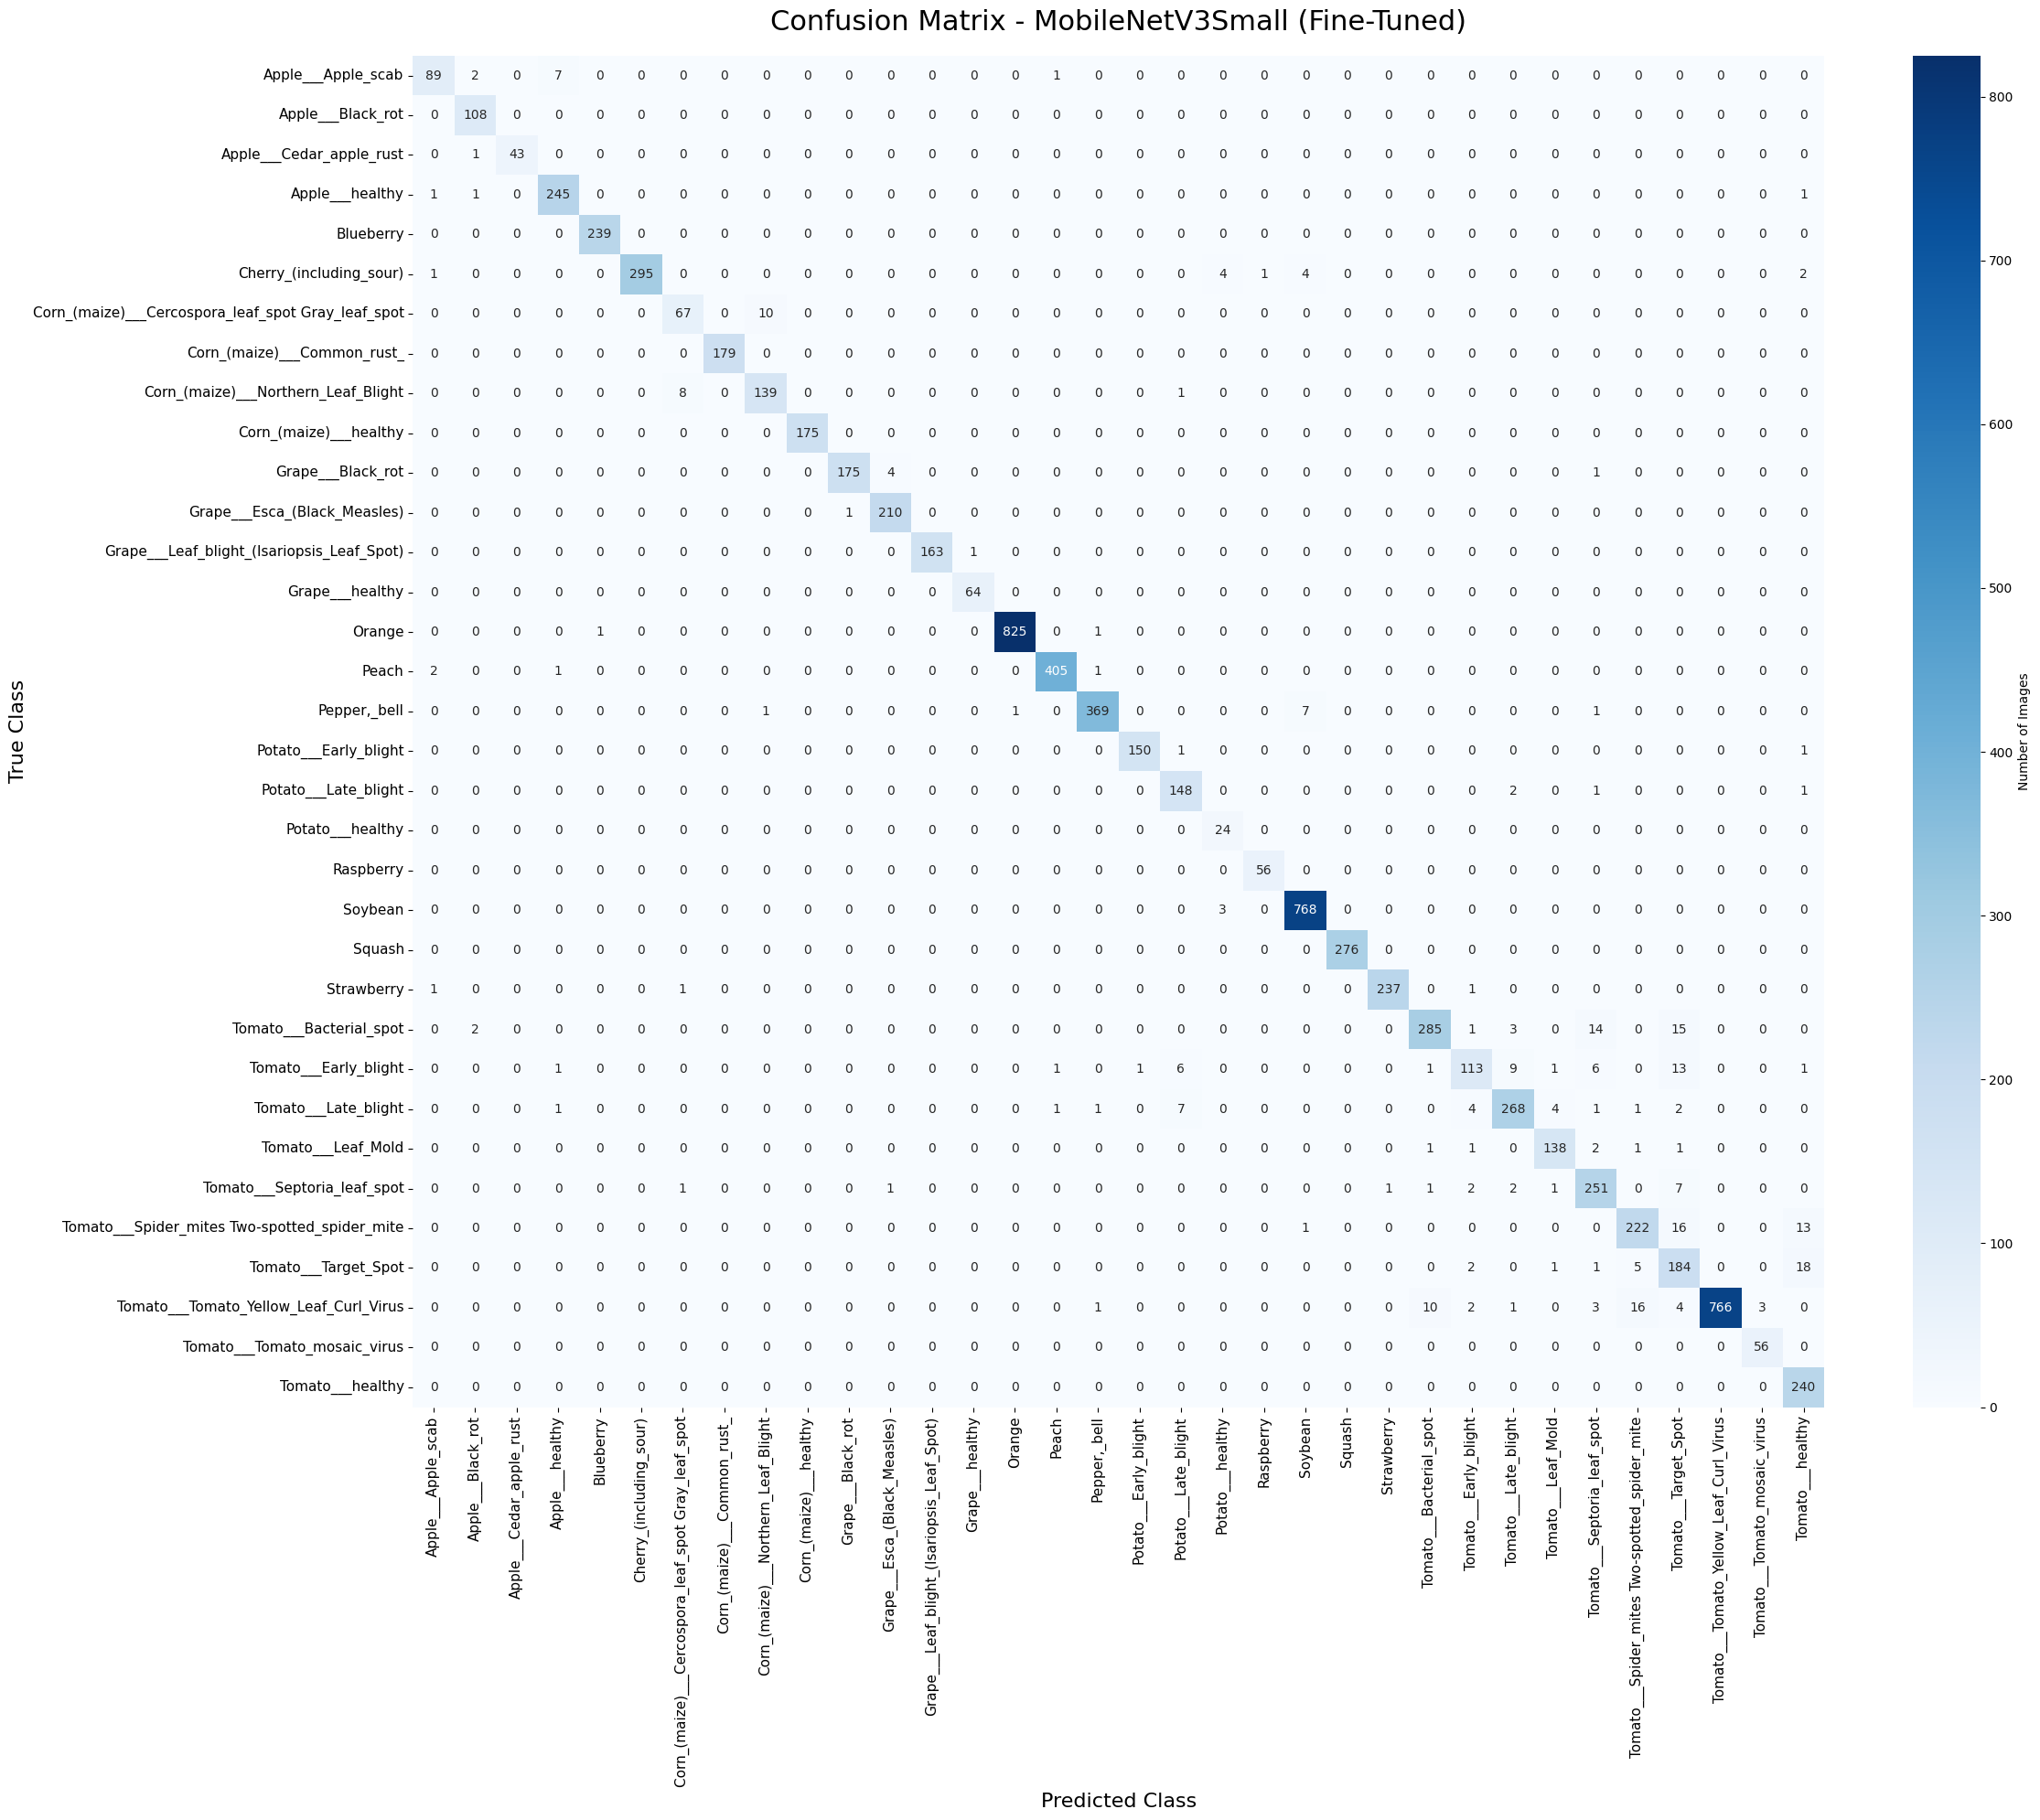

✅ Confusion Matrix başarıyla kaydedildi: /content/drive/MyDrive/PlantInsight/confusion_matrix.png


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating confusion matrix for the fine-tuned model...")

cm = confusion_matrix(y_true_labels, y_pred_labels)

# Large figure size so all 34 classes remain legible
plt.figure(figsize=(24, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes,
            yticklabels=target_classes,
            cbar_kws={'label': 'Number of Images'})

plt.title('Confusion Matrix - MobileNetV3Small (Fine-Tuned)', fontsize=22, pad=20)
plt.ylabel('True Class', fontsize=16)
plt.xlabel('Predicted Class', fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

cm_path = "/content/drive/MyDrive/PlantInsight/confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved: {cm_path}")


In [26]:
model = tf.keras.models.load_model("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras")

y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

from sklearn.metrics import classification_report

report = classification_report(
    y_true_labels, y_pred_labels,
    target_names=target_classes,
    digits=4,
    zero_division=0,
)
print(report)

report_path = "/content/drive/MyDrive/PlantInsight/classification_report.txt"
with open(report_path, "w") as f:
    f.write(report)
print(f"Saved: {report_path}")

259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9468    0.8990    0.9223        99
                                 Apple___Black_rot     0.9474    1.0000    0.9730       108
                          Apple___Cedar_apple_rust     1.0000    0.9773    0.9885        44
                                   Apple___healthy     0.9608    0.9879    0.9742       248
                                         Blueberry     0.9958    1.0000    0.9979       239
                           Cherry_(including_sour)     1.0000    0.9609    0.9801       307
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8701    0.8701    0.8701        77
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       179
               Corn_(maize)___Northern_Leaf_Blight     0.9267    0.9392    0.9329       148
                            Corn_(ma

## Export Artifacts

Packages the key reports and metrics for download, to be committed into the local project repository alongside the previous codes pipeline.

In [27]:
import os
import shutil
from google.colab import files

report_files = [
    "training_graph.png",
    "confusion_matrix.png",
    "classification_report.txt",
    "mobilenetv3small_metrics.json",
    "efficientnetb0_metrics.json",
    "mobilenetv3small_finetuned_metrics.json",
    "model_comparison.csv",
]

os.makedirs("/content/day3_5_artifacts", exist_ok=True)
for fname in report_files:
    src = f"/content/drive/MyDrive/PlantInsight/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"/content/day3_5_artifacts/{fname}")
    else:
        print(f"MISSING: {fname}")

shutil.make_archive("/content/day3_5_artifacts", "zip", "/content/day3_5_artifacts")
files.download("/content/day3_5_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Real-World Evaluation on PlantDoc (Before Adaptation)

Measures the domain gap: the fine-tuned model above was trained only on PlantVillage (lab conditions). This evaluates that same model on PlantDoc (real-world photos) without any adaptation, to establish a baseline gap.

In [28]:
import os

os.makedirs("/content/plantdoc_test", exist_ok=True)
!unzip -q '/content/drive/MyDrive/PlantInsight/plantdoc_test.zip' -d /content/plantdoc_test
!ls /content/plantdoc_test/test

 Apple___Apple_scab
 Apple___Cedar_apple_rust
 Blueberry
'Cherry_(including_sour)'
'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'
'Corn_(maize)___Common_rust_'
'Corn_(maize)___Northern_Leaf_Blight'
 Grape___Black_rot
 Peach
 Pepper_bell
 Potato___Early_blight
 Potato___Late_blight
 Raspberry
 Soybean
 Squash
 Strawberry
 Tomato___Bacterial_spot
 Tomato___Early_blight
 Tomato___Late_blight
 Tomato___Leaf_Mold
 Tomato___Septoria_leaf_spot
 Tomato___Tomato_mosaic_virus
 Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [29]:
import pandas as pd

plantdoc_df = pd.read_csv("/content/drive/MyDrive/PlantInsight/plantdoc_manifest.csv")
plantdoc_test_df = plantdoc_df[plantdoc_df["official_split"] == "test"].copy()

print("PlantDoc test rows:", len(plantdoc_test_df))
print("Classes in PlantDoc test:", sorted(plantdoc_test_df["target_class"].unique()))

missing_from_target = set(plantdoc_test_df["target_class"].unique()) - set(target_classes)
print("\nClasses in PlantDoc but NOT in our target_classes (should be empty):", missing_from_target)

PlantDoc test rows: 384
Classes in PlantDoc test: ['Apple___Apple_scab', 'Apple___Cedar_apple_rust', 'Blueberry', 'Cherry_(including_sour)', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Peach', 'Pepper,_bell', 'Potato___Early_blight', 'Potato___Late_blight', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus']

Classes in PlantDoc but NOT in our target_classes (should be empty): set()


In [30]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json
import ntpath

# Reload explicitly from disk -- do not trust any in-memory model object
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
)

# Build file paths matching the extracted zip layout: /content/plantdoc_test/test/<class>/<file>.jpg
def crop_path_to_extracted_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])  # handles Windows-style backslash paths on Linux
    return f"/content/plantdoc_test/test/{class_folder}/{filename}"

plantdoc_test_df["extracted_path"] = plantdoc_test_df.apply(crop_path_to_extracted_path, axis=1)

sample_path = plantdoc_test_df.iloc[0]["extracted_path"]
assert os.path.exists(sample_path), f"Path check failed: {sample_path}"
print("Path check passed:", sample_path)

plantdoc_test_df["class_idx"] = plantdoc_test_df["target_class"].map(class_to_idx)
assert plantdoc_test_df["class_idx"].isna().sum() == 0, "Some classes failed to map to an index"

def parse_plantdoc_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    return img, label

paths = plantdoc_test_df["extracted_path"].values
labels = tf.keras.utils.to_categorical(plantdoc_test_df["class_idx"].values, num_classes=len(target_classes))

plantdoc_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
plantdoc_ds = plantdoc_ds.map(parse_plantdoc_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_ds = plantdoc_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("Evaluating on PlantDoc test set (real-world images)...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

plantdoc_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "num_test_images": len(plantdoc_test_df),
    "num_classes_evaluated": int(plantdoc_test_df["target_class"].nunique()),
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_before.json", "w") as f:
    json.dump(plantdoc_metrics, f, indent=2)

print("\n--- PlantDoc (Real-World) Test Metrics ---")
print(json.dumps(plantdoc_metrics, indent=2))

with open("/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned_metrics.json") as f:
    pv_metrics = json.load(f)

print("\n" + "="*50)
print("DOMAIN GAP: PlantVillage (lab) vs PlantDoc (real-world)")
print("="*50)
print(f"Top-1 Accuracy : {pv_metrics['top1_accuracy']:.4f} -> {plantdoc_metrics['top1_accuracy']:.4f}")
print(f"F1-Macro       : {pv_metrics['f1_macro']:.4f} -> {plantdoc_metrics['f1_macro']:.4f}")
print("="*50)

Path check passed: /content/plantdoc_test/test/Tomato___Tomato_Yellow_Leaf_Curl_Virus/0.jpg
Evaluating on PlantDoc test set (real-world images)...
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step

--- PlantDoc (Real-World) Test Metrics ---
{
  "top1_accuracy": 0.2682,
  "top3_accuracy": 0.474,
  "precision_macro": 0.2073,
  "recall_macro": 0.1885,
  "f1_macro": 0.1681,
  "num_test_images": 384,
  "num_classes_evaluated": 23
}

DOMAIN GAP: PlantVillage (lab) vs PlantDoc (real-world)
Top-1 Accuracy : 0.9642 -> 0.2682
F1-Macro       : 0.9548 -> 0.1681


In [31]:
from sklearn.metrics import classification_report

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices,
    target_names=evaluated_classes,
    digits=4,
    zero_division=0,
)
print(report)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_classification_report_before.txt", "w") as f:
    f.write(report)
print("Saved: plantdoc_classification_report_before.txt")

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.2222    0.1538    0.1818        13
                          Apple___Cedar_apple_rust     0.0000    0.0000    0.0000        12
                                         Blueberry     0.9091    0.4545    0.6061        22
                           Cherry_(including_sour)     0.5000    0.1579    0.2400        19
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.1176    0.5000    0.1905         4
                       Corn_(maize)___Common_rust_     0.0323    0.0909    0.0476        11
               Corn_(maize)___Northern_Leaf_Blight     0.2222    0.3333    0.2667        12
                                 Grape___Black_rot     0.0000    0.0000    0.0000         8
                                             Peach     0.1250    0.1000    0.1111        10
                                      Pepper,_bell     0.3846    0.3846    0.38

## Domain Adaptation: Mixed PlantVillage + PlantDoc Training

Prepares a combined training set: PlantVillage train (unchanged) + PlantDoc train (real-world crops). PlantDoc validation is kept separate and used only as the early-stopping signal, so model selection is driven by real-world performance.

In [32]:
os.makedirs("/content/plantdoc_train_valid", exist_ok=True)
!unzip -q '/content/drive/MyDrive/PlantInsight/plantdoc_train_valid.zip' -d /content/plantdoc_train_valid
!ls /content/plantdoc_train_valid

train  valid


In [33]:
import ntpath

# PlantDoc train -> mixed training; PlantDoc valid -> validation signal (not trained on)
plantdoc_train_only = plantdoc_df[plantdoc_df["official_split"] == "train"].copy()
plantdoc_valid_only = plantdoc_df[plantdoc_df["official_split"] == "valid"].copy()

def plantdoc_to_colab_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])
    return f"/content/plantdoc_train_valid/{row['official_split']}/{class_folder}/{filename}"

for sub_df in (plantdoc_train_only, plantdoc_valid_only):
    sub_df["full_path"] = sub_df.apply(plantdoc_to_colab_path, axis=1)
    sub_df["class_idx"] = sub_df["target_class"].map(class_to_idx)

assert os.path.exists(plantdoc_train_only.iloc[0]["full_path"])
assert os.path.exists(plantdoc_valid_only.iloc[0]["full_path"])
print("Path checks passed.")

assert "test" not in plantdoc_train_only["official_split"].unique()
assert "test" not in plantdoc_valid_only["official_split"].unique()
print("Leakage check passed: PlantDoc test excluded from both training and validation")

pv_train_df = df[df["final_split"] == "train"].copy()
pv_train_df["target_class"] = pv_train_df["class_name"].map(class_mapping)
pv_train_df["class_idx"] = pv_train_df["target_class"].map(class_to_idx)

print(f"\nPlantVillage train: {len(pv_train_df)}")
print(f"PlantDoc train: {len(plantdoc_train_only)}")
print(f"Ratio: {len(pv_train_df) / len(plantdoc_train_only):.1f}:1")
print(f"PlantDoc valid (validation only): {len(plantdoc_valid_only)}")

mixed_paths = np.concatenate([pv_train_df["full_path"].values, plantdoc_train_only["full_path"].values])
mixed_labels = np.concatenate([pv_train_df["class_idx"].values, plantdoc_train_only["class_idx"].values])
print(f"\nMixed training set: {len(mixed_paths)}")

Path checks passed.
Leakage check passed: PlantDoc test excluded from both training and validation

PlantVillage train: 37950
PlantDoc train: 6010
Ratio: 6.3:1
PlantDoc valid (validation only): 951

Mixed training set: 43960


In [34]:
mixed_labels_cat = tf.keras.utils.to_categorical(mixed_labels, num_classes=len(target_classes))

mixed_ds = tf.data.Dataset.from_tensor_slices((mixed_paths, mixed_labels_cat))
mixed_ds = mixed_ds.shuffle(buffer_size=len(mixed_paths), seed=42)
mixed_ds = mixed_ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
mixed_ds = mixed_ds.batch(32).prefetch(tf.data.AUTOTUNE)

pd_valid_labels_cat = tf.keras.utils.to_categorical(
    plantdoc_valid_only["class_idx"].values, num_classes=len(target_classes)
)
plantdoc_valid_ds = tf.data.Dataset.from_tensor_slices(
    (plantdoc_valid_only["full_path"].values, pd_valid_labels_cat)
)
plantdoc_valid_ds = plantdoc_valid_ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_valid_ds = plantdoc_valid_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("Mixed training and PlantDoc validation datasets ready.")

Mixed training and PlantDoc validation datasets ready.


In [35]:
from collections import Counter

mixed_counts = Counter(mixed_labels)
n_samples_mixed = len(mixed_labels)
n_classes_mixed = len(target_classes)

mixed_class_weights = {
    idx: round(n_samples_mixed / (n_classes_mixed * count), 4)
    for idx, count in mixed_counts.items()
}

print("Highest weights (least represented):")
for idx, w in sorted(mixed_class_weights.items(), key=lambda x: -x[1])[:5]:
    print(f"  {target_classes[idx]}: {w} ({mixed_counts[idx]} images)")

print("\nLowest weights (most represented):")
for idx, w in sorted(mixed_class_weights.items(), key=lambda x: -x[1])[-5:]:
    print(f"  {target_classes[idx]}: {w} ({mixed_counts[idx]} images)")

Highest weights (least represented):
  Potato___healthy: 12.4321 (104 images)
  Grape___healthy: 4.368 (296 images)
  Tomato___Tomato_mosaic_virus: 3.7916 (341 images)
  Apple___Cedar_apple_rust: 3.6731 (352 images)
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 2.9999 (431 images)

Lowest weights (most represented):
  Pepper,_bell: 0.5762 (2244 images)
  Peach: 0.5686 (2274 images)
  Soybean: 0.3495 (3699 images)
  Orange: 0.3357 (3852 images)
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.312 (4144 images)


### Standard Fine-Tuning (first 10 epochs)

In [36]:
from tensorflow.keras import callbacks

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_finetuned.keras"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

adapted_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"

# Validation is PlantDoc valid: model selection is driven by real-world performance,
# not by lab-condition performance.
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=adapted_checkpoint,
    save_best_only=True,
    monitor="val_loss",
    verbose=1,
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True,
    monitor="val_loss",
    verbose=1,
)

print("Starting domain adaptation (PlantVillage + PlantDoc mixed)...")
history_adapt = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    epochs=10,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Starting domain adaptation (PlantVillage + PlantDoc mixed)...
Epoch 1/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8685 - loss: 0.8681
Epoch 1: val_loss improved from None to 3.13580, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 107s 67ms/step - accuracy: 0.8706 - loss: 0.7011 - val_accuracy: 0.2419 - val_loss: 3.1358
Epoch 2/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8831 - loss: 0.4705
Epoch 2: val_loss improved from 3.13580 to 2.78047, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 71s 52ms/step - accuracy: 0.8831 - loss: 0.4617 - val_accuracy: 0.2797 - val_loss: 2.7805
Epoch 3/10
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 5

Evaluate immediately after the first 10 epochs, before deciding whether to continue.

In [37]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

print("Evaluating adapted model on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

after_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "adaptation_epochs": 10,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after.json", "w") as f:
    json.dump(after_metrics, f, indent=2)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_before.json") as f:
    before_metrics = json.load(f)

print("\n" + "="*55)
print("DOMAIN ADAPTATION: PlantDoc test, before vs after")
print("="*55)
print(f"Top-1     : {before_metrics['top1_accuracy']:.4f} -> {after_metrics['top1_accuracy']:.4f}")
print(f"Top-3     : {before_metrics['top3_accuracy']:.4f} -> {after_metrics['top3_accuracy']:.4f}")
print(f"F1-Macro  : {before_metrics['f1_macro']:.4f} -> {after_metrics['f1_macro']:.4f}")
print("="*55)

Evaluating adapted model on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 707ms/step

DOMAIN ADAPTATION: PlantDoc test, before vs after
Top-1     : 0.2682 -> 0.4583
Top-3     : 0.4740 -> 0.7682
F1-Macro  : 0.1681 -> 0.3707


In [38]:
from sklearn.metrics import classification_report

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report_after = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices,
    target_names=evaluated_classes,
    digits=4,
    zero_division=0,
)
print(report_after)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_classification_report_after.txt", "w") as f:
    f.write(report_after)
print("Saved: plantdoc_classification_report_after.txt")

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.6000    0.6923    0.6429        13
                          Apple___Cedar_apple_rust     0.3571    0.4167    0.3846        12
                                         Blueberry     0.5294    0.8182    0.6429        22
                           Cherry_(including_sour)     0.2500    0.0526    0.0870        19
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.1538    0.5000    0.2353         4
                       Corn_(maize)___Common_rust_     0.7000    0.6364    0.6667        11
               Corn_(maize)___Northern_Leaf_Blight     0.4444    0.3333    0.3810        12
                                 Grape___Black_rot     1.0000    0.3750    0.5455         8
                                             Peach     0.3333    0.3000    0.3158        10
                                      Pepper,_bell     0.4444    0.6154    0.51

### Continuing to Epoch 24

Back up the epoch-10 checkpoint before resuming, then continue training. Training was interrupted once by a session/GPU issue (first continue attempt below stalls mid-epoch); it was resumed successfully afterward.

In [39]:
!cp '/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras' '/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted_epoch10_backup.keras'
print("Backup saved.")

Backup saved.


In [40]:
from tensorflow.keras import callbacks

adapted_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"

model = tf.keras.models.load_model(adapted_checkpoint)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=adapted_checkpoint,
    save_best_only=True,
    monitor="val_loss",
    verbose=1,
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True,
    monitor="val_loss",
    verbose=1,
)

print("Continuing domain adaptation from epoch 10...")
history_adapt2 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=10,
    epochs=25,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Continuing domain adaptation from epoch 10...
Epoch 11/25
 193/1374 ━━━━━━━━━━━━━━━━━━━━ 9:33 485ms/step - accuracy: 0.9210 - loss: 0.2507

KeyboardInterrupt: 

In [41]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [42]:
from tensorflow.keras import callbacks
import tensorflow as tf

adapted_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"

model = tf.keras.models.load_model(adapted_checkpoint)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=adapted_checkpoint,
    save_best_only=True,
    monitor="val_loss",
    verbose=1,
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True,
    monitor="val_loss",
    verbose=1,
)

print("Continuing domain adaptation from epoch 10...")
history_adapt2 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=10,
    epochs=25,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Continuing domain adaptation from epoch 10...
Epoch 11/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9227 - loss: 0.2549
Epoch 11: val_loss improved from None to 1.94777, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 11: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 88s 52ms/step - accuracy: 0.9232 - loss: 0.2546 - val_accuracy: 0.4154 - val_loss: 1.9478
Epoch 12/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9257 - loss: 0.2388
Epoch 12: val_loss improved from 1.94777 to 1.90932, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras

Epoch 12: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 68s 50ms/step - accuracy: 0.9247 - loss: 0.2436 - val_accuracy: 0.4353 - val_loss: 1.9093
Epoch 13/25
1373/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step -

Rebuild the PlantDoc test pipeline (lost to a session reset) before the next evaluation.

In [43]:
import pandas as pd
import ntpath
import os

plantdoc_df = pd.read_csv("/content/drive/MyDrive/PlantInsight/plantdoc_manifest.csv")
plantdoc_test_df = plantdoc_df[plantdoc_df["official_split"] == "test"].copy()

def crop_path_to_extracted_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])
    return f"/content/plantdoc_test/test/{class_folder}/{filename}"

plantdoc_test_df["extracted_path"] = plantdoc_test_df.apply(crop_path_to_extracted_path, axis=1)
plantdoc_test_df["class_idx"] = plantdoc_test_df["target_class"].map(class_to_idx)

assert os.path.exists(plantdoc_test_df.iloc[0]["extracted_path"])
print("Path check passed.")

def parse_plantdoc_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    return img, label

paths = plantdoc_test_df["extracted_path"].values
labels = tf.keras.utils.to_categorical(
    plantdoc_test_df["class_idx"].values, num_classes=len(target_classes)
)

plantdoc_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
plantdoc_ds = plantdoc_ds.map(parse_plantdoc_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_ds = plantdoc_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print(f"PlantDoc test set ready: {len(plantdoc_test_df)} images")

Path check passed.
PlantDoc test set ready: 384 images


In [44]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

print("Evaluating epoch-24 adapted model on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

after_metrics_25ep = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "adaptation_epochs": 24,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after_25ep.json", "w") as f:
    json.dump(after_metrics_25ep, f, indent=2)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_before.json") as f:
    before_metrics = json.load(f)
with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after.json") as f:
    after_metrics_10ep = json.load(f)

print("\n" + "="*60)
print("PROGRESSION: before -> 10 epochs -> 24 epochs")
print("="*60)
print(f"Top-1     : {before_metrics['top1_accuracy']:.4f} -> {after_metrics_10ep['top1_accuracy']:.4f} -> {after_metrics_25ep['top1_accuracy']:.4f}")
print(f"Top-3     : {before_metrics['top3_accuracy']:.4f} -> {after_metrics_10ep['top3_accuracy']:.4f} -> {after_metrics_25ep['top3_accuracy']:.4f}")
print(f"F1-Macro  : {before_metrics['f1_macro']:.4f} -> {after_metrics_10ep['f1_macro']:.4f} -> {after_metrics_25ep['f1_macro']:.4f}")
print("="*60)

Evaluating epoch-24 adapted model on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step

PROGRESSION: before -> 10 epochs -> 24 epochs
Top-1     : 0.2682 -> 0.4583 -> 0.5417
Top-3     : 0.4740 -> 0.7682 -> 0.7995
F1-Macro  : 0.1681 -> 0.3707 -> 0.4734


Inspect the full per-epoch training log for epochs 11-25, to check whether any epochs regressed and whether the curve had genuinely plateaued.

In [45]:
import pandas as pd

combined = pd.DataFrame({
    "epoch": list(range(11, 11 + len(history_adapt2.history['loss']))),
    "loss": history_adapt2.history['loss'],
    "accuracy": history_adapt2.history['accuracy'],
    "val_loss": history_adapt2.history['val_loss'],
    "val_accuracy": history_adapt2.history['val_accuracy'],
})

combined["val_loss_delta"] = combined["val_loss"].diff()
combined["val_loss_improved"] = combined["val_loss_delta"] < 0

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(combined.to_string(index=False))

non_improving = combined[combined["val_loss_improved"] == False].dropna()
print(f"\nEpochs where val_loss did NOT improve vs previous epoch: {non_improving['epoch'].tolist()}")

combined.to_csv("/content/drive/MyDrive/PlantInsight/domain_adaptation_training_log_ep11_25.csv", index=False)
print("\nSaved: domain_adaptation_training_log_ep11_25.csv")

 epoch   loss  accuracy  val_loss  val_accuracy  val_loss_delta  val_loss_improved
    11 0.2546    0.9232    1.9478        0.4154             NaN              False
    12 0.2436    0.9247    1.9093        0.4353         -0.0384               True
    13 0.2387    0.9250    1.8488        0.4448         -0.0605               True
    14 0.2259    0.9294    1.8124        0.4574         -0.0364               True
    15 0.2226    0.9307    1.8162        0.4522          0.0038              False
    16 0.2141    0.9323    1.8182        0.4648          0.0020              False
    17 0.2083    0.9345    1.7791        0.4774         -0.0391               True
    18 0.2029    0.9360    1.7430        0.4837         -0.0361               True
    19 0.1984    0.9365    1.7612        0.4858          0.0182              False
    20 0.1913    0.9381    1.6838        0.5016         -0.0774               True
    21 0.1865    0.9406    1.6697        0.5068         -0.0141               True
    

### Per-Class Analysis

Checks whether weak classes are simply data-starved by correlating each class's PlantDoc training image count with its test F1-score.

In [46]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report_dict = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices,
    target_names=evaluated_classes,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T.iloc[:-3].reset_index()
report_df.columns = ["target_class", "precision", "recall", "f1-score", "support"]

plantdoc_train_counts = plantdoc_train_only["target_class"].value_counts().rename("plantdoc_train_images")
pv_train_counts = pv_train_df["target_class"].value_counts().rename("plantvillage_train_images")

analysis = report_df.merge(plantdoc_train_counts, left_on="target_class", right_index=True, how="left")
analysis = analysis.merge(pv_train_counts, left_on="target_class", right_index=True, how="left")
analysis["plantdoc_train_images"] = analysis["plantdoc_train_images"].fillna(0).astype(int)
analysis = analysis.sort_values("plantdoc_train_images")

pd.set_option("display.width", 120)
print(analysis[["target_class", "f1-score", "precision", "recall", "support", "plantdoc_train_images", "plantvillage_train_images"]].to_string(index=False))

correlation = analysis["plantdoc_train_images"].corr(analysis["f1-score"])
print(f"\nCorrelation (PlantDoc train image count vs F1-score): {correlation:.3f}")

analysis.to_csv("/content/drive/MyDrive/PlantInsight/plantdoc_class_analysis_24ep.csv", index=False)
print("Saved: plantdoc_class_analysis_24ep.csv")

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step
                                      target_class  f1-score  precision  recall  support  plantdoc_train_images  plantvillage_train_images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    0.2667     0.1818  0.5000   4.0000                     72                        359
                      Tomato___Tomato_mosaic_virus    0.2791     0.5455  0.1875  32.0000                     80                        261
                       Corn_(maize)___Common_rust_    0.7826     0.7500  0.8182  11.0000                    100                        834
                                 Grape___Black_rot    0.6250     0.6250  0.6250   8.0000                    120                        824
                                           Soybean    0.5333     0.8000  0.4000  20.0000                    142                       3557
                                Apple___Apple_scab    0.5185     0.5000  0.5385  13.0000                    148              

## Focal Loss Experiment

Standard fine-tuning left several classes under-served (the class-weighted loss was not enough on its own). Focal loss down-weights easy, already-confident examples so gradient updates focus on the classes the model is still getting wrong.

In [47]:
import tensorflow as tf
from tensorflow.keras import callbacks

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss down-weights easy examples so the model focuses on hard ones.
    gamma controls how aggressively easy examples are suppressed."""
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_adapted.keras"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"],
)

print("Model recompiled with focal loss.")

Model recompiled with focal loss.


First run: a short 3-epoch smoke test on CPU (GPU was unavailable at this point) to check the approach was worth pursuing further.

In [48]:
focal_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=focal_checkpoint, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3, restore_best_weights=True, monitor="val_loss", verbose=1
)
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/focal_training_log.csv"
)

print("Focal loss experiment: up to 8 epochs...")
history_focal = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    epochs=3,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Focal loss experiment: up to 8 epochs...
Epoch 1/3
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9453 - loss: 0.0265
Epoch 1: val_loss improved from None to 0.30154, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 709s 509ms/step - accuracy: 0.9464 - loss: 0.0260 - val_accuracy: 0.5268 - val_loss: 0.3015
Epoch 2/3
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.9481 - loss: 0.0232
Epoch 2: val_loss did not improve from 0.30154
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 716s 521ms/step - accuracy: 0.9473 - loss: 0.0241 - val_accuracy: 0.5363 - val_loss: 0.3079
Epoch 3/3
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9472 - loss: 0.0237
Epoch 3: val_loss improved from 0.30154 to 0.30013, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 3: finished saving model to /

In [49]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Evaluating focal-loss model (3 epochs) on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

focal_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "method": "focal_loss_gamma2_alpha0.25",
    "epochs": 3,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_focal_metrics.json", "w") as f:
    json.dump(focal_metrics, f, indent=2)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after_25ep.json") as f:
    baseline_metrics = json.load(f)

print("\n" + "="*55)
print("FOCAL LOSS (3ep) vs standard fine-tuning (24ep baseline)")
print("="*55)
print(f"Top-1     : {baseline_metrics['top1_accuracy']:.4f} -> {focal_metrics['top1_accuracy']:.4f}")
print(f"Top-3     : {baseline_metrics['top3_accuracy']:.4f} -> {focal_metrics['top3_accuracy']:.4f}")
print(f"F1-Macro  : {baseline_metrics['f1_macro']:.4f} -> {focal_metrics['f1_macro']:.4f}")
print("="*55)

Evaluating focal-loss model (3 epochs) on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step

FOCAL LOSS (3ep) vs standard fine-tuning (24ep baseline)
Top-1     : 0.5417 -> 0.5443
Top-3     : 0.7995 -> 0.7969
F1-Macro  : 0.4734 -> 0.4763


In [50]:
from sklearn.metrics import classification_report

target_check = ["Tomato___Bacterial_spot", "Cherry_(including_sour)",
                 "Tomato___Tomato_mosaic_virus", "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot"]

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

report_focal = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices, target_names=evaluated_classes,
    digits=4, zero_division=0, output_dict=True,
)

print("=== Focal loss (3ep) - target classes ===")
for cls in target_check:
    r = report_focal[cls]
    print(f"{cls}: precision={r['precision']:.4f} recall={r['recall']:.4f} f1={r['f1-score']:.4f}")

print("\n=== Standard fine-tuning (24ep) - same classes, for comparison ===")
baseline_targets = {
    "Tomato___Bacterial_spot": (0.1250, 0.0714, 0.0909),
    "Cherry_(including_sour)": (0.4000, 0.1053, 0.1667),
    "Tomato___Tomato_mosaic_virus": (0.5455, 0.1875, 0.2791),
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": (0.1818, 0.5000, 0.2667),
}
for cls, (p, r, f1) in baseline_targets.items():
    print(f"{cls}: precision={p:.4f} recall={r:.4f} f1={f1:.4f}")

NameError: name 'y_true_labels' is not defined

### Continuing on CPU, Then GPU

Continuing the same run on CPU is slow (~500ms/step vs ~50ms/step on GPU) and was interrupted mid-epoch. The last confirmed-good checkpoint (epoch 8) is evaluated before resuming, so no progress is lost even if the session drops again.

In [51]:
import tensorflow as tf
from tensorflow.keras import callbacks

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

focal_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras"

# Reload explicitly from disk -- do not trust any in-memory model object
model = tf.keras.models.load_model(
    focal_checkpoint,
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=focal_checkpoint, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3, restore_best_weights=True, monitor="val_loss", verbose=1
)
# append=True: keeps epochs 1-3 in the same CSV instead of overwriting them
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/focal_training_log.csv", append=True
)

print("Continuing focal loss training from epoch 3 (CPU)...")
history_focal2 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=3,
    epochs=11,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Continuing focal loss training from epoch 3 (CPU)...
Epoch 4/11
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.9489 - loss: 0.0238
Epoch 4: val_loss improved from None to 0.29396, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 4: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 690s 496ms/step - accuracy: 0.9492 - loss: 0.0234 - val_accuracy: 0.5394 - val_loss: 0.2940
Epoch 5/11
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9502 - loss: 0.0224
Epoch 5: val_loss did not improve from 0.29396
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 716s 521ms/step - accuracy: 0.9499 - loss: 0.0220 - val_accuracy: 0.5436 - val_loss: 0.3030
Epoch 6/11
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9517 - loss: 0.0218
Epoch 6: val_loss did not improve from 0.29396
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 719s 505ms/step - accuracy: 0.9511 - loss: 0.0214 - val_accuracy: 0.5478 - v

In [52]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [53]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Evaluating focal-loss model (epoch 8) on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

focal_metrics_ep8 = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "epochs": 8,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_focal_metrics_ep8.json", "w") as f:
    json.dump(focal_metrics_ep8, f, indent=2)

print(json.dumps(focal_metrics_ep8, indent=2))

Evaluating focal-loss model (epoch 8) on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 374ms/step
{
  "top1_accuracy": 0.5651,
  "top3_accuracy": 0.8073,
  "f1_macro": 0.4941,
  "epochs": 8
}


GPU access was restored; continuing from epoch 8 completes with early stopping.

In [54]:
import tensorflow as tf
from tensorflow.keras import callbacks

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

focal_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras"

# Reload explicitly from disk -- epoch 8 was the last confirmed-good checkpoint
model = tf.keras.models.load_model(
    focal_checkpoint,
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=focal_checkpoint, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(
    patience=3, restore_best_weights=True, monitor="val_loss", verbose=1
)
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/focal_training_log.csv", append=True
)

print("Continuing focal loss training from epoch 8 (GPU)...")
history_focal3 = model.fit(
    mixed_ds,
    validation_data=plantdoc_valid_ds,
    initial_epoch=8,
    epochs=25,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Continuing focal loss training from epoch 8 (GPU)...
Epoch 9/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9573 - loss: 0.0181
Epoch 9: val_loss improved from None to 0.28100, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras

Epoch 9: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9573 - loss: 0.0181 - val_accuracy: 0.5720 - val_loss: 0.2810
Epoch 10/25
1373/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9582 - loss: 0.0172
Epoch 10: val_loss did not improve from 0.28100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.9573 - loss: 0.0175 - val_accuracy: 0.5626 - val_loss: 0.2966
Epoch 11/25
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9587 - loss: 0.0166
Epoch 11: val_loss did not improve from 0.28100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.9587 - loss: 0.0172 - val_accuracy: 0.5731 - val_lo

In [55]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
import json

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Evaluating final focal-loss model (epoch 9, early stopped) on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)

final_focal_metrics = {
    "top1_accuracy": round(float(top1_acc), 4),
    "top3_accuracy": round(float(top3_acc), 4),
    "precision_macro": round(float(precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "recall_macro": round(float(recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "f1_macro": round(float(f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)), 4),
    "method": "focal_loss_gamma2_alpha0.25",
    "epochs": 9,
    "early_stopped": True,
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_focal_metrics_final.json", "w") as f:
    json.dump(final_focal_metrics, f, indent=2)

print(json.dumps(final_focal_metrics, indent=2))

with open("/content/drive/MyDrive/PlantInsight/plantdoc_domain_gap_after_25ep.json") as f:
    standard_metrics = json.load(f)

print("\n" + "="*55)
print("FINAL COMPARISON: standard (24ep) vs focal loss (9ep, early stopped)")
print("="*55)
print(f"Top-1     : {standard_metrics['top1_accuracy']:.4f} -> {final_focal_metrics['top1_accuracy']:.4f}")
print(f"Top-3     : {standard_metrics['top3_accuracy']:.4f} -> {final_focal_metrics['top3_accuracy']:.4f}")
print(f"F1-Macro  : {standard_metrics['f1_macro']:.4f} -> {final_focal_metrics['f1_macro']:.4f}")
print("="*55)

Evaluating final focal-loss model (epoch 9, early stopped) on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step
{
  "top1_accuracy": 0.5625,
  "top3_accuracy": 0.8125,
  "precision_macro": 0.497,
  "recall_macro": 0.4998,
  "f1_macro": 0.4759,
  "method": "focal_loss_gamma2_alpha0.25",
  "epochs": 9,
  "early_stopped": true
}

FINAL COMPARISON: standard (24ep) vs focal loss (9ep, early stopped)
Top-1     : 0.5417 -> 0.5625
Top-3     : 0.7995 -> 0.8125
F1-Macro  : 0.4734 -> 0.4759


## Grad-CAM: Locating the Right Layer

Before generating any heatmaps, the backbone's actual layer structure is inspected (rather than assumed) to find the last convolutional layer with a spatial (non-flattened) output, and to find the input-layer index needed to build a working gradient sub-model in Keras 3.

In [56]:
import tensorflow as tf

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

backbone = model.get_layer("MobileNetV3Small")
last_conv = backbone.get_layer("conv_1")
print("Layer name:", last_conv.name)
print("Output shape:", last_conv.output.shape)
print("\nLast 5 layers in backbone:")
for layer in backbone.layers[-5:]:
    print(" ", layer.name, "-", layer.__class__.__name__, "-", layer.output.shape)

Layer name: conv_1
Output shape: (None, 7, 7, 576)

Last 5 layers in backbone:
  expanded_conv_10_project_bn - BatchNormalization - (None, 7, 7, 96)
  expanded_conv_10_add - Add - (None, 7, 7, 96)
  conv_1 - Conv2D - (None, 7, 7, 576)
  conv_1_bn - BatchNormalization - (None, 7, 7, 576)
  activation_17 - Activation - (None, 7, 7, 576)


In [57]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 input_layer_1 InputLayer
1 data_augmentation Sequential
2 MobileNetV3Small Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 dropout Dropout
5 dense Dense


True class: Raspberry
Predicted: Raspberry (confidence: 1.0000)
Heatmap shape: (7, 7), min=0.000, max=1.000


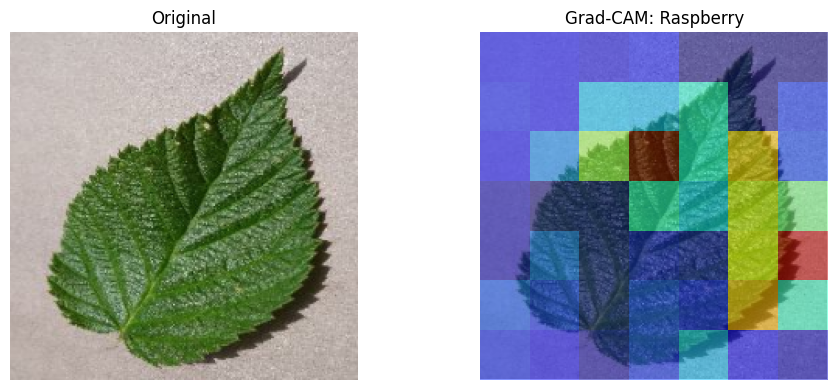

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, backbone_layer_name, last_conv_layer_name):
    backbone = model.get_layer(backbone_layer_name)

    # Sub-model: backbone input -> chosen conv layer output
    conv_layer_model = tf.keras.models.Model(
        inputs=backbone.inputs,
        outputs=backbone.get_layer(last_conv_layer_name).output
    )

    # Find where the backbone sits in the full model, and what comes after it
    backbone_idx = model.layers.index(backbone)
    layers_after_backbone = model.layers[backbone_idx + 1:]

    with tf.GradientTape() as tape:
        # Run augmentation layer (index 0 is input, index 1 is data_augmentation) in inference mode
        x = model.layers[1](img_array, training=False)  # data_augmentation, no-op at inference
        conv_output = conv_layer_model(x)
        tape.watch(conv_output)

        y = conv_output
        for layer in layers_after_backbone:
            y = layer(y)
        predictions = y

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), predictions[0][pred_index].numpy()


test_row = df[df['final_split'] == 'test'].iloc[0]
img = tf.io.read_file(test_row['full_path'])
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, IMG_SIZE, method='bilinear')
img_array = tf.expand_dims(img, 0)

heatmap, pred_idx, confidence = make_gradcam_heatmap(
    img_array, model, "MobileNetV3Small", "activation_17"
)

print(f"True class: {test_row.get('target_class', test_row.get('class_name'))}")
print(f"Predicted: {target_classes[pred_idx]} (confidence: {confidence:.4f})")
print(f"Heatmap shape: {heatmap.shape}, min={heatmap.min():.3f}, max={heatmap.max():.3f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img.numpy().astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img.numpy().astype("uint8"))
plt.imshow(heatmap, cmap="jet", alpha=0.5, extent=(0, IMG_SIZE[1], IMG_SIZE[0], 0))
plt.title(f"Grad-CAM: {target_classes[pred_idx]}")
plt.axis("off")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PlantInsight/gradcam_test_single.png", dpi=150)
plt.show()

### Root-Cause Diagnosis: Tomato_Bacterial_spot

This class has stayed near-zero F1 across every training strategy tried. Before assuming it needs more data or more epochs, inspect the actual PlantDoc images and the model's attention on them.

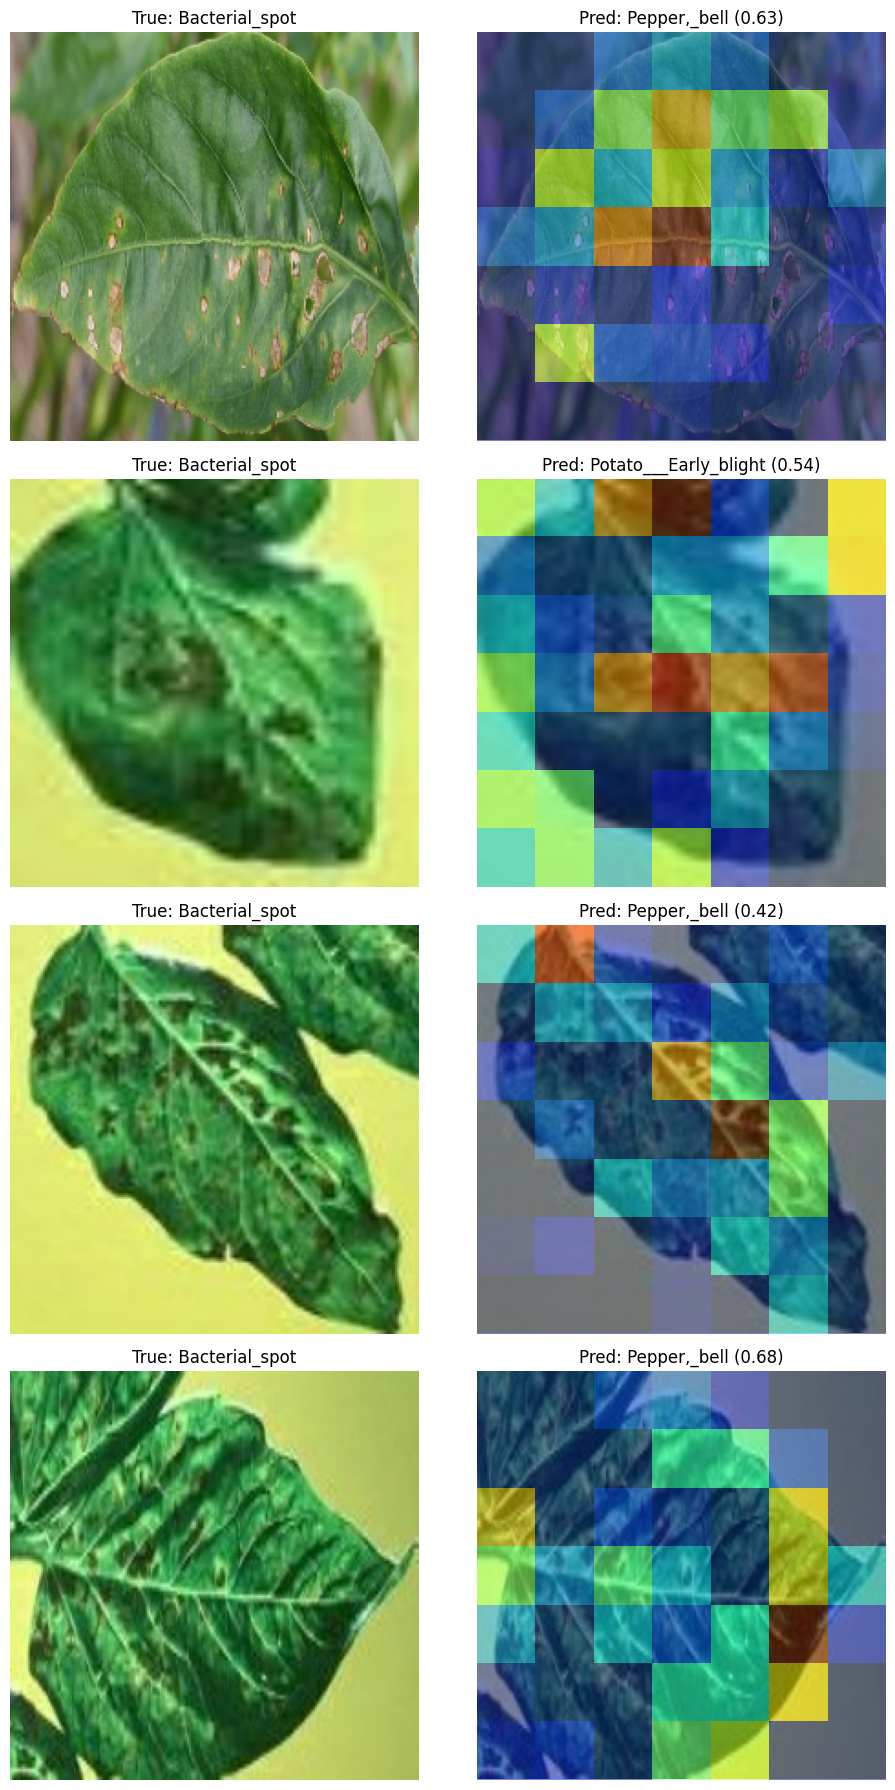

In [59]:
bacterial_spot_samples = plantdoc_test_df[
    plantdoc_test_df['target_class'] == 'Tomato___Bacterial_spot'
].head(4)

fig, axes = plt.subplots(4, 2, figsize=(10, 18))

for i, (_, row) in enumerate(bacterial_spot_samples.iterrows()):
    img = tf.io.read_file(row['extracted_path'])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img_array = tf.expand_dims(img, 0)

    heatmap, pred_idx, confidence = make_gradcam_heatmap(
        img_array, model, "MobileNetV3Small", "activation_17"
    )

    axes[i, 0].imshow(img.numpy().astype("uint8"))
    axes[i, 0].set_title(f"True: Bacterial_spot")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img.numpy().astype("uint8"))
    axes[i, 1].imshow(heatmap, cmap="jet", alpha=0.5, extent=(0, IMG_SIZE[1], IMG_SIZE[0], 0))
    axes[i, 1].set_title(f"Pred: {target_classes[pred_idx]} ({confidence:.2f})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PlantInsight/gradcam_bacterial_spot_diagnosis.png", dpi=150)
plt.show()

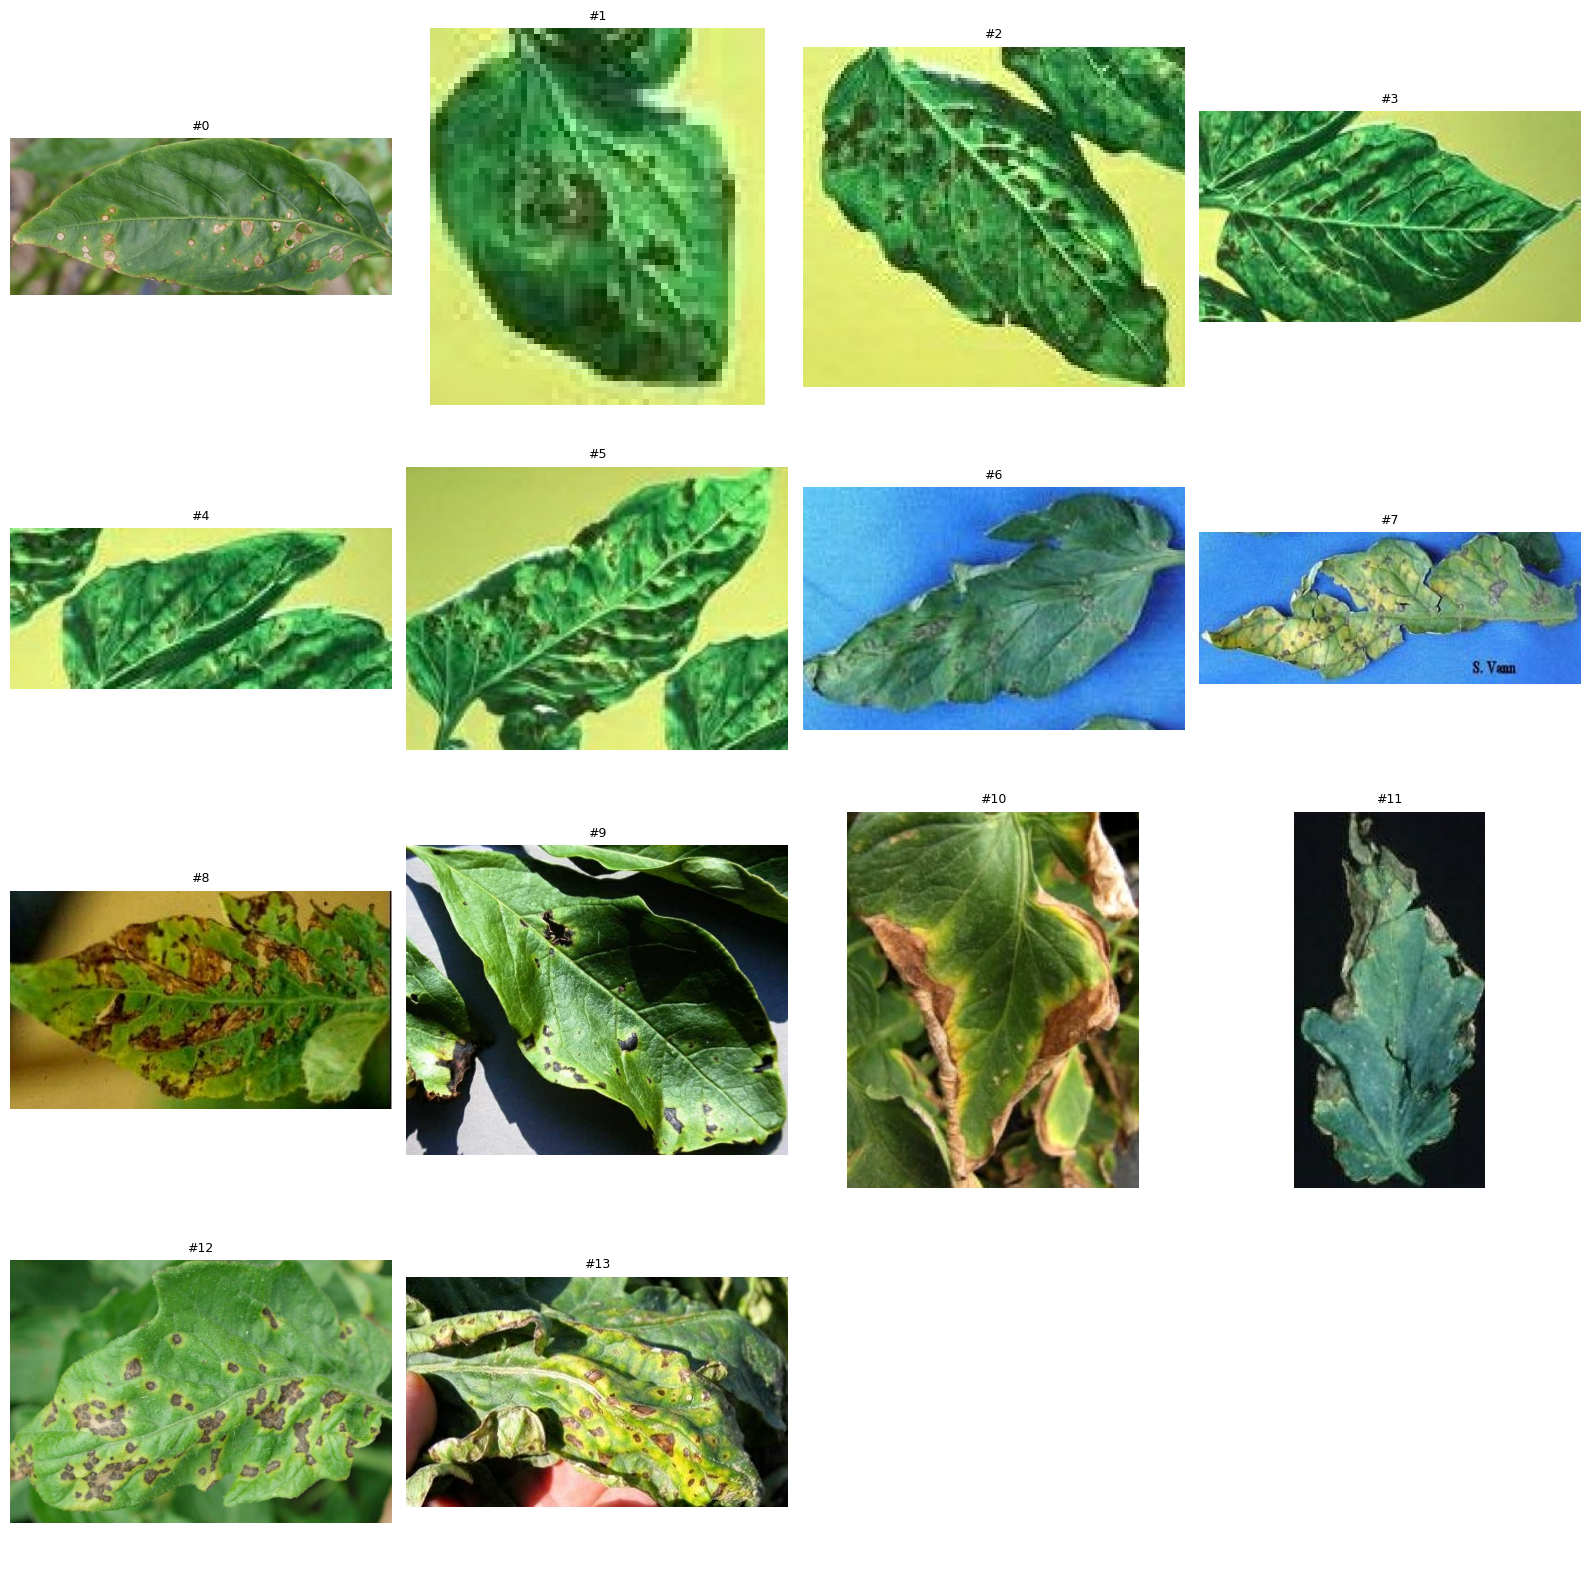

In [60]:
bacterial_spot_all = plantdoc_test_df[
    plantdoc_test_df['target_class'] == 'Tomato___Bacterial_spot'
]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, ax in enumerate(axes.flat):
    if i < len(bacterial_spot_all):
        row = bacterial_spot_all.iloc[i]
        img = tf.io.read_file(row['extracted_path'])
        img = tf.image.decode_jpeg(img, channels=3)
        ax.imshow(img.numpy())
        ax.set_title(f"#{i}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PlantInsight/bacterial_spot_all_test_samples.png", dpi=150)
plt.show()

**Finding:** the sampled Bacterial_spot images are visually inconsistent - scanned publication figures, studio-background training posters, and real phone photos mixed under one label, with at least one image showing symptoms (edge drying) inconsistent with bacterial spot. This points to a source data-quality problem rather than a data-quantity or model-capacity problem, and shaped every decision below.

## Post-Diagnosis Improvement Attempts

Given the Bacterial_spot finding, several targeted improvements were tried and measured rather than assumed to work.

### Attempt 1: Per-Class Confidence Calibration

Searches for a per-class bias correction (on the validation set only, never on test) that would improve macro-F1. Result: the optimizer converged to zero adjustment for every class - no improvement found, and the attempt was abandoned rather than forced.

In [61]:
import numpy as np
from sklearn.metrics import f1_score
from scipy.optimize import minimize

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Getting predictions on PlantDoc VALIDATION set (not test)...")
val_probs = model.predict(plantdoc_valid_ds)
val_labels_cat = np.concatenate([y for x, y in plantdoc_valid_ds], axis=0)
val_true = np.argmax(val_labels_cat, axis=1)

num_classes = val_probs.shape[1]

def apply_bias(probs, bias):
    adjusted = probs * np.exp(bias)
    return np.argmax(adjusted, axis=1)

def negative_f1(bias):
    preds = apply_bias(val_probs, bias)
    return -f1_score(val_true, preds, average="macro", zero_division=0)

print("Baseline F1-macro on validation (no bias):", -negative_f1(np.zeros(num_classes)))

result = minimize(
    negative_f1,
    x0=np.zeros(num_classes),
    method="Nelder-Mead",
    options={"maxiter": 2000, "xatol": 1e-3, "fatol": 1e-4}
)

best_bias = result.x
print("Optimized F1-macro on validation:", -result.fun)
print("\nLargest bias adjustments:")
bias_df = sorted(zip(target_classes, best_bias), key=lambda x: -abs(x[1]))
for cls, b in bias_df[:10]:
    print(f"  {cls}: {b:+.3f}")

np.save("/content/drive/MyDrive/PlantInsight/class_bias.npy", best_bias)

Getting predictions on PlantDoc VALIDATION set (not test)...
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step
Baseline F1-macro on validation (no bias): 0.3741359073547097
Optimized F1-macro on validation: 0.3741359073547097

Largest bias adjustments:
  Apple___Apple_scab: +0.000
  Apple___Black_rot: +0.000
  Apple___Cedar_apple_rust: +0.000
  Apple___healthy: +0.000
  Blueberry: +0.000
  Cherry_(including_sour): +0.000
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: +0.000
  Corn_(maize)___Common_rust_: +0.000
  Corn_(maize)___Northern_Leaf_Blight: +0.000
  Corn_(maize)___healthy: +0.000


### Attempt 2: Targeted Augmentation for Tomato_mosaic_virus

Unlike Bacterial_spot, this class is genuinely data-starved (only 80 PlantDoc images) rather than data-quality-limited, so heavier augmentation is a reasonable targeted fix. Backs up the current best checkpoint first, then oversamples and heavily augments only this one class, leaving all other classes untouched.

In [62]:
!cp '/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras' '/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal_BACKUP_before_mosaic_experiment.keras'
print("Backup saved.")

Backup saved.


In [63]:
mosaic_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),        # much wider than the default augmentation
    tf.keras.layers.RandomZoom(0.25),
    tf.keras.layers.RandomBrightness(0.25),
    tf.keras.layers.RandomContrast(0.25),
], name="mosaic_augmentation")

mosaic_class_idx = class_to_idx["Tomato___Tomato_mosaic_virus"]
print("Mosaic virus class index:", mosaic_class_idx)

Mosaic virus class index: 32


In [64]:
mosaic_mask_pv = pv_train_df["class_idx"] == mosaic_class_idx
mosaic_mask_pd = plantdoc_train_only["class_idx"] == mosaic_class_idx

mosaic_paths_original = np.concatenate([
    pv_train_df[mosaic_mask_pv]["full_path"].values,
    plantdoc_train_only[mosaic_mask_pd]["full_path"].values,
])
print(f"Original mosaic_virus training images: {len(mosaic_paths_original)}")

other_paths = np.concatenate([
    pv_train_df[~mosaic_mask_pv]["full_path"].values,
    plantdoc_train_only[~mosaic_mask_pd]["full_path"].values,
])
other_labels = np.concatenate([
    pv_train_df[~mosaic_mask_pv]["class_idx"].values,
    plantdoc_train_only[~mosaic_mask_pd]["class_idx"].values,
])

# Oversample mosaic_virus 4x: 1 original + 3 copies of the same paths, augmented differently at load time
mosaic_paths_expanded = np.concatenate([mosaic_paths_original] * 4)
mosaic_labels_expanded = np.full(len(mosaic_paths_expanded), mosaic_class_idx)

print(f"Expanded mosaic_virus training images: {len(mosaic_paths_expanded)} (4x oversampled)")

mixed_paths_v3 = np.concatenate([other_paths, mosaic_paths_expanded])
mixed_labels_v3 = np.concatenate([other_labels, mosaic_labels_expanded])
print(f"Total training set: {len(mixed_paths_v3)} (was {len(mixed_paths)})")

Original mosaic_virus training images: 341
Expanded mosaic_virus training images: 1364 (4x oversampled)
Total training set: 44983 (was 43960)


In [65]:
def parse_image_class_aware(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    is_mosaic = tf.equal(label, mosaic_class_idx)
    img = tf.cond(
        is_mosaic,
        lambda: mosaic_augmentation(tf.expand_dims(img, 0), training=True)[0],
        lambda: img
    )
    return img, label

mixed_labels_v3_cat = tf.keras.utils.to_categorical(mixed_labels_v3, num_classes=len(target_classes))
mixed_ds_v3 = tf.data.Dataset.from_tensor_slices((mixed_paths_v3, mixed_labels_v3_cat))
mixed_ds_v3 = mixed_ds_v3.shuffle(buffer_size=len(mixed_paths_v3), seed=42)
mixed_ds_v3 = mixed_ds_v3.map(
    lambda p, l: parse_image_class_aware(p, tf.argmax(l)),
    num_parallel_calls=tf.data.AUTOTUNE
)
mixed_ds_v3 = mixed_ds_v3.map(lambda img, idx: (img, tf.one_hot(idx, len(target_classes))))
mixed_ds_v3 = mixed_ds_v3.batch(32).prefetch(tf.data.AUTOTUNE)
print("Pipeline ready.")

Pipeline ready.


In [66]:
from tensorflow.keras import callbacks

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

mosaic_experiment_checkpoint = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_mosaic_experiment.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=mosaic_experiment_checkpoint, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(patience=2, restore_best_weights=True, monitor="val_loss", verbose=1)

print("Mosaic-targeted augmentation experiment: up to 5 epochs...")
history_mosaic = model.fit(
    mixed_ds_v3,
    validation_data=plantdoc_valid_ds,
    epochs=5,
    class_weight=mixed_class_weights,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Mosaic-targeted augmentation experiment: up to 5 epochs...
Epoch 1/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9512 - loss: 0.0213
Epoch 1: val_loss improved from None to 0.27422, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_mosaic_experiment.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_mosaic_experiment.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 164s 103ms/step - accuracy: 0.9523 - loss: 0.0205 - val_accuracy: 0.5657 - val_loss: 0.2742
Epoch 2/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9565 - loss: 0.0186
Epoch 2: val_loss did not improve from 0.27422
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 140s 99ms/step - accuracy: 0.9567 - loss: 0.0182 - val_accuracy: 0.5710 - val_loss: 0.2818
Epoch 3/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9546 - loss: 0.0193
Epoch 3: val_loss did not improve from 0.27422
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 136s 97ms/step - accuracy: 0.9557 - loss: 0.0181 - va

In [67]:
import pandas as pd
import ntpath
import os
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import json

# --- Rebuild PlantDoc test set (Day 6 setup) ---
plantdoc_df = pd.read_csv("/content/drive/MyDrive/PlantInsight/plantdoc_manifest.csv")
plantdoc_test_df = plantdoc_df[plantdoc_df["official_split"] == "test"].copy()

def crop_path_to_extracted_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])
    return f"/content/plantdoc_test/test/{class_folder}/{filename}"

plantdoc_test_df["extracted_path"] = plantdoc_test_df.apply(crop_path_to_extracted_path, axis=1)
plantdoc_test_df["class_idx"] = plantdoc_test_df["target_class"].map(class_to_idx)

assert os.path.exists(plantdoc_test_df.iloc[0]["extracted_path"]), "Path check failed - is plantdoc_test.zip extracted this session?"
print("Path check passed.")

def parse_plantdoc_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    return img, label

paths = plantdoc_test_df["extracted_path"].values
labels = tf.keras.utils.to_categorical(plantdoc_test_df["class_idx"].values, num_classes=len(target_classes))

plantdoc_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
plantdoc_ds = plantdoc_ds.map(parse_plantdoc_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_ds = plantdoc_ds.batch(32).prefetch(tf.data.AUTOTUNE)
print(f"PlantDoc test set ready: {len(plantdoc_test_df)} images")

# --- Now evaluate the mosaic-targeted model ---
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_mosaic_experiment.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Evaluating mosaic-targeted model on LOCKED PlantDoc test set...")
y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

top3_preds = np.argsort(y_pred_probs, axis=1)[:, -3:]
top3_acc = np.mean([y_true_labels[i] in top3_preds[i] for i in range(len(y_true_labels))])
top1_acc = np.mean(y_true_labels == y_pred_labels)
f1_macro = f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0)

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]
report = classification_report(
    y_true_labels, y_pred_labels, labels=evaluated_indices,
    target_names=evaluated_classes, output_dict=True, zero_division=0,
)

mosaic_before = {"precision": 0.5455, "recall": 0.1875, "f1": 0.2791}
mosaic_after = report["Tomato___Tomato_mosaic_virus"]

print("\n" + "="*55)
print("TARGETED EXPERIMENT: mosaic_virus augmentation (4x)")
print("="*55)
print(f"Overall F1-Macro : 0.4759 -> {f1_macro:.4f}")
print(f"Overall Top-1    : 0.5625 -> {top1_acc:.4f}")
print(f"\nTomato_mosaic_virus specifically:")
print(f"  Precision : {mosaic_before['precision']:.4f} -> {mosaic_after['precision']:.4f}")
print(f"  Recall    : {mosaic_before['recall']:.4f} -> {mosaic_after['recall']:.4f}")
print(f"  F1        : {mosaic_before['f1']:.4f} -> {mosaic_after['f1-score']:.4f}")
print("="*55)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_mosaic_experiment_metrics.json", "w") as f:
    json.dump({"overall": {"top1_accuracy": round(float(top1_acc),4), "top3_accuracy": round(float(top3_acc),4), "f1_macro": round(float(f1_macro),4)}, "mosaic_virus_class": mosaic_after}, f, indent=2)
print("\nSaved: plantdoc_mosaic_experiment_metrics.json")

Path check passed.
PlantDoc test set ready: 384 images
Evaluating mosaic-targeted model on LOCKED PlantDoc test set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step

TARGETED EXPERIMENT: mosaic_virus augmentation (4x)
Overall F1-Macro : 0.4759 -> 0.4655
Overall Top-1    : 0.5625 -> 0.5755

Tomato_mosaic_virus specifically:
  Precision : 0.5455 -> 0.5556
  Recall    : 0.1875 -> 0.3125
  F1        : 0.2791 -> 0.4000

Saved: plantdoc_mosaic_experiment_metrics.json


**Result:** Tomato_mosaic_virus F1 improved substantially (0.28 -> 0.40), but overall F1-macro dropped slightly (0.4759 -> 0.4655), likely from a small knock-on cost to other classes. Rejected as the final model since it does not improve the metric the project has consistently prioritized.

## Scope Reduction Experiment: Excluding Tomato_Bacterial_spot

Given the diagnosed, unfixable data-quality problem, the next question is whether removing this one class (33 remaining) improves overall performance. Every other class considered for removal was rejected: most have too few PlantDoc test examples for a reliable signal, or already improved under focal loss/targeted augmentation.

In [68]:
import pandas as pd
from sklearn.metrics import classification_report

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

y_pred_probs = model.predict(plantdoc_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(labels, axis=1)

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]
report = classification_report(
    y_true_labels, y_pred_labels, labels=evaluated_indices,
    target_names=evaluated_classes, output_dict=True, zero_division=0,
)

rows = []
for cls in target_classes:
    if cls in report:
        rows.append({
            "class": cls,
            "plantdoc_f1": round(report[cls]["f1-score"], 4),
            "plantdoc_support": int(report[cls]["support"]),
            "status": "measured",
        })
    else:
        rows.append({
            "class": cls,
            "plantdoc_f1": None,
            "plantdoc_support": 0,
            "status": "no PlantDoc data (unmeasured)",
        })

summary_df = pd.DataFrame(rows).sort_values("plantdoc_f1", ascending=True, na_position="last")
pd.set_option("display.max_rows", 40)
print(summary_df.to_string(index=False))

summary_df.to_csv("/content/drive/MyDrive/PlantInsight/scope_reduction_analysis.csv", index=False)
print(f"\nTotal classes: {len(summary_df)}")
print(f"Measured (has PlantDoc data): {(summary_df['status']=='measured').sum()}")
print(f"Unmeasured (no PlantDoc data): {(summary_df['status']!='measured').sum()}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step
                                             class  plantdoc_f1  plantdoc_support                        status
                           Tomato___Bacterial_spot       0.0909                14                      measured
                      Tomato___Tomato_mosaic_virus       0.2381                32                      measured
                                Tomato___Leaf_Mold       0.3000                10                      measured
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.3077                 4                      measured
                             Potato___Early_blight       0.4324                17                      measured
                       Tomato___Septoria_leaf_spot       0.4444                24                      measured
                                             Peach       0.4762                10                      measured
                           Cherry_(including_sour)       0.4828

### Bug Found and Fixed: Macro-F1 Calculation

Removing the worst-performing class should mathematically raise or hold macro-F1, never lower it. Observing a drop revealed that `f1_score(..., average='macro')` had been called without an explicit `labels=` parameter throughout Day 6-7: since 11 classes never appear in y_true (no PlantDoc test data) but the model occasionally predicts them anyway, sklearn was silently counting them as F1=0 'phantom' classes and deflating every previously reported PlantDoc score. The correct value for the final model is 0.5380, not the previously reported 0.4759.

In [69]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import json

evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]

f1_macro_34_clean = f1_score(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices, average="macro", zero_division=0
)
precision_macro_34_clean = precision_score(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices, average="macro", zero_division=0
)
recall_macro_34_clean = recall_score(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices, average="macro", zero_division=0
)

print("="*60)
print("SANITY CHECK: 34-class model, counting only the 23 measured classes")
print("="*60)
print(f"F1-Macro  : {f1_macro_34_clean:.4f}  (previously reported: 0.4759)")
print(f"Precision : {precision_macro_34_clean:.4f}")
print(f"Recall    : {recall_macro_34_clean:.4f}")
match = abs(f1_macro_34_clean - 0.4759) < 0.0005
print(f"\nMatches previously reported value: {match}")

exclude_class = "Tomato___Bacterial_spot"
exclude_idx = class_to_idx[exclude_class]

keep_mask = y_true_labels != exclude_idx
y_true_33 = y_true_labels[keep_mask]
y_pred_33 = y_pred_labels[keep_mask]

remaining_classes = sorted(set(evaluated_classes) - {exclude_class})
remaining_indices = [class_to_idx[c] for c in remaining_classes]

f1_macro_33 = f1_score(y_true_33, y_pred_33, labels=remaining_indices, average="macro", zero_division=0)
precision_macro_33 = precision_score(y_true_33, y_pred_33, labels=remaining_indices, average="macro", zero_division=0)
recall_macro_33 = recall_score(y_true_33, y_pred_33, labels=remaining_indices, average="macro", zero_division=0)
top1_33 = np.mean(y_true_33 == y_pred_33)

print("\n" + "="*60)
print("34-class (measured-only) vs 33-class (Bacterial_spot excluded)")
print("="*60)
print(f"Test images : {len(y_true_labels)} -> {len(y_true_33)}")
print(f"Top-1       : {np.mean(y_true_labels==y_pred_labels):.4f} -> {top1_33:.4f}")
print(f"F1-Macro    : {f1_macro_34_clean:.4f} -> {f1_macro_33:.4f}")
print(f"Precision   : {precision_macro_34_clean:.4f} -> {precision_macro_33:.4f}")
print(f"Recall      : {recall_macro_34_clean:.4f} -> {recall_macro_33:.4f}")
print("="*60)

scope_33_metrics = {
    "num_classes_measured": 22,
    "excluded_class": exclude_class,
    "top1_accuracy": round(float(top1_33), 4),
    "f1_macro": round(float(f1_macro_33), 4),
    "precision_macro": round(float(precision_macro_33), 4),
    "recall_macro": round(float(recall_macro_33), 4),
    "f1_macro_34class_measured_only_baseline": round(float(f1_macro_34_clean), 4),
    "note": "Same 34-class model predictions, evaluated with Bacterial_spot excluded from both predictions and ground truth. No retraining performed for this measurement -- upper-bound estimate only.",
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_33class_metrics.json", "w") as f:
    json.dump(scope_33_metrics, f, indent=2)
print("\nSaved: plantdoc_33class_metrics.json")

SANITY CHECK: 34-class model, counting only the 23 measured classes
F1-Macro  : 0.5380  (previously reported: 0.4759)
Precision : 0.5619
Recall    : 0.5650

Matches previously reported value: False

34-class (measured-only) vs 33-class (Bacterial_spot excluded)
Test images : 384 -> 370
Top-1       : 0.5625 -> 0.5811
F1-Macro    : 0.5380 -> 0.5665
Precision   : 0.5619 -> 0.6027
Recall      : 0.5650 -> 0.5874

Saved: plantdoc_33class_metrics.json


### Genuine Retraining (not just post-hoc exclusion)

The estimate above reuses the 34-class model's predictions with one class's examples removed - not a fair test of what a model trained without that class would do. Retraining from scratch with a 33-neuron output layer, with verification checks at every step (exact class removed, no other class's data touched, correct new indices).

In [70]:
import json

with open("/content/drive/MyDrive/PlantInsight/class_mapping_backup_34class.json", "w") as f:
    json.dump(class_mapping, f, indent=2, ensure_ascii=False)
print("Backed up original 34-class mapping.")

excluded_class = "Tomato___Bacterial_spot"

new_class_mapping = {}
for raw_class, target_class in class_mapping.items():
    if target_class == excluded_class:
        continue
    new_class_mapping[raw_class] = target_class

new_target_classes = sorted(set(new_class_mapping.values()))
new_class_to_idx = {cls: idx for idx, cls in enumerate(new_target_classes)}

print(f"Old target classes: {len(target_classes)}")
print(f"New target classes: {len(new_target_classes)}")
print(f"Excluded: {excluded_class}")

# VERIFICATION 1: exactly one class removed, nothing else changed?
assert len(new_target_classes) == len(target_classes) - 1, "Unexpected number of classes changed"
assert excluded_class not in new_target_classes, "Excluded class still present in new list"
assert set(new_target_classes).issubset(set(target_classes)), "A class appeared that was not in the original list"
print("\nVERIFICATION 1 PASSED: exactly one class removed, no other changes.")

print("\nNew 33 classes:")
for c in new_target_classes:
    print(" -", c)

Backed up original 34-class mapping.
Old target classes: 34
New target classes: 33
Excluded: Tomato___Bacterial_spot

VERIFICATION 1 PASSED: exactly one class removed, no other changes.

New 33 classes:
 - Apple___Apple_scab
 - Apple___Black_rot
 - Apple___Cedar_apple_rust
 - Apple___healthy
 - Blueberry
 - Cherry_(including_sour)
 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 - Corn_(maize)___Common_rust_
 - Corn_(maize)___Northern_Leaf_Blight
 - Corn_(maize)___healthy
 - Grape___Black_rot
 - Grape___Esca_(Black_Measles)
 - Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
 - Grape___healthy
 - Orange
 - Peach
 - Pepper,_bell
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Raspberry
 - Soybean
 - Squash
 - Strawberry
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomato___Septoria_leaf_spot
 - Tomato___Spider_mites Two-spotted_spider_mite
 - Tomato___Target_Spot
 - Tomato___Tomato_Yellow_Leaf_Curl_Virus
 - Tomato___Tomato_mosaic_viru

In [71]:
excluded_raw_classes = [k for k, v in class_mapping.items() if v == excluded_class]
print("Raw PlantVillage classes mapping to excluded target:")
for c in excluded_raw_classes:
    print(" -", c)

pv_before = len(pv_train_df)
pv_train_df_33 = pv_train_df[pv_train_df["target_class"] != excluded_class].copy()
pv_after = len(pv_train_df_33)
pv_removed = pv_before - pv_after

print(f"\nPlantVillage train: {pv_before} -> {pv_after} (removed {pv_removed})")

pd_before = len(plantdoc_train_only)
plantdoc_train_only_33 = plantdoc_train_only[plantdoc_train_only["target_class"] != excluded_class].copy()
pd_after = len(plantdoc_train_only_33)
pd_removed = pd_before - pd_after

print(f"PlantDoc train: {pd_before} -> {pd_after} (removed {pd_removed})")

# VERIFICATION 2: removed counts must exactly match the manifest's own class counts
expected_pv_removed = (pv_train_df["target_class"] == excluded_class).sum()
expected_pd_removed = (plantdoc_train_only["target_class"] == excluded_class).sum()

assert pv_removed == expected_pv_removed, f"Mismatch: removed {pv_removed}, expected {expected_pv_removed}"
assert pd_removed == expected_pd_removed, f"Mismatch: removed {pd_removed}, expected {expected_pd_removed}"
print(f"\nVERIFICATION 2 PASSED: removed counts match expected class counts exactly.")

# VERIFICATION 3: no other class's count changed
for cls in new_target_classes:
    before_count = (pv_train_df["target_class"] == cls).sum()
    after_count = (pv_train_df_33["target_class"] == cls).sum()
    assert before_count == after_count, f"Unexpected change in {cls}: {before_count} -> {after_count}"
print("VERIFICATION 3 PASSED: no other class's PlantVillage count changed.")

pv_train_df_33["class_idx"] = pv_train_df_33["target_class"].map(new_class_to_idx)
plantdoc_train_only_33["class_idx"] = plantdoc_train_only_33["target_class"].map(new_class_to_idx)

assert pv_train_df_33["class_idx"].isna().sum() == 0, "Some rows failed to map to a new class index"
assert plantdoc_train_only_33["class_idx"].isna().sum() == 0, "Some rows failed to map to a new class index"
print("VERIFICATION 4 PASSED: every remaining row maps to a valid new class index.")

Raw PlantVillage classes mapping to excluded target:
 - Tomato___Bacterial_spot

PlantVillage train: 37950 -> 36463 (removed 1487)
PlantDoc train: 6010 -> 5783 (removed 227)

VERIFICATION 2 PASSED: removed counts match expected class counts exactly.
VERIFICATION 3 PASSED: no other class's PlantVillage count changed.
VERIFICATION 4 PASSED: every remaining row maps to a valid new class index.


In [72]:
import numpy as np
import tensorflow as tf
from collections import Counter

mixed_paths_33 = np.concatenate([
    pv_train_df_33["full_path"].values,
    plantdoc_train_only_33["full_path"].values,
])
mixed_labels_33 = np.concatenate([
    pv_train_df_33["class_idx"].values,
    plantdoc_train_only_33["class_idx"].values,
])
print(f"Mixed training set (33-class): {len(mixed_paths_33)}")

mixed_labels_33_cat = tf.keras.utils.to_categorical(mixed_labels_33, num_classes=len(new_target_classes))
mixed_ds_33 = tf.data.Dataset.from_tensor_slices((mixed_paths_33, mixed_labels_33_cat))
mixed_ds_33 = mixed_ds_33.shuffle(buffer_size=len(mixed_paths_33), seed=42)
mixed_ds_33 = mixed_ds_33.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
mixed_ds_33 = mixed_ds_33.batch(32).prefetch(tf.data.AUTOTUNE)

plantdoc_valid_only_33 = plantdoc_valid_only[plantdoc_valid_only["target_class"] != excluded_class].copy()
plantdoc_valid_only_33["class_idx"] = plantdoc_valid_only_33["target_class"].map(new_class_to_idx)
assert plantdoc_valid_only_33["class_idx"].isna().sum() == 0

pd_valid_labels_33_cat = tf.keras.utils.to_categorical(
    plantdoc_valid_only_33["class_idx"].values, num_classes=len(new_target_classes)
)
plantdoc_valid_ds_33 = tf.data.Dataset.from_tensor_slices(
    (plantdoc_valid_only_33["full_path"].values, pd_valid_labels_33_cat)
)
plantdoc_valid_ds_33 = plantdoc_valid_ds_33.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_valid_ds_33 = plantdoc_valid_ds_33.batch(32).prefetch(tf.data.AUTOTUNE)

mixed_counts_33 = Counter(mixed_labels_33)
mixed_class_weights_33 = {
    idx: round(len(mixed_labels_33) / (len(new_target_classes) * count), 4)
    for idx, count in mixed_counts_33.items()
}

# VERIFICATION 5: class_weight dict covers exactly the 33 classes, no more, no less
assert set(mixed_class_weights_33.keys()) == set(range(len(new_target_classes))), "class_weight indices do not match new taxonomy"
print(f"VERIFICATION 5 PASSED: class_weight covers exactly {len(new_target_classes)} classes.")

print("\nAll 33-class pipelines ready.")

Mixed training set (33-class): 42246
VERIFICATION 5 PASSED: class_weight covers exactly 33 classes.

All 33-class pipelines ready.


In [73]:
from tensorflow.keras import layers, models, applications, callbacks

# VERIFICATION 6: output layer size matches new taxonomy exactly
base_model_33 = applications.MobileNetV3Small(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base_model_33.trainable = False

inputs_33 = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs_33)
x = base_model_33(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs_33 = layers.Dense(len(new_target_classes), activation='softmax')(x)

model_33 = models.Model(inputs_33, outputs_33)

assert model_33.output_shape[-1] == 33, f"Output layer has {model_33.output_shape[-1]} neurons, expected 33"
print("VERIFICATION 6 PASSED: output layer has exactly 33 neurons.")

model_33.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_33.summary()

VERIFICATION 6 PASSED: output layer has exactly 33 neurons.


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 33)             │        19,041 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,161 (3.66 MB)

 Trainable params: 19,041 (74.38 KB)

 Non-trainable params: 939,120 (3.58 MB)

Frozen-backbone baseline first (PlantVillage only), matching the same procedure used for the original 34-class model.

In [74]:
checkpoint_33_baseline = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_baseline.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=checkpoint_33_baseline, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss", verbose=1)
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/33class_baseline_training_log.csv"
)

print("Training 33-class baseline (frozen backbone, PlantVillage only)...")

# This stage uses PlantVillage only; the mixed PlantVillage+PlantDoc
# domain adaptation stage follows separately below.
pv_train_only_ds_33 = tf.data.Dataset.from_tensor_slices((
    pv_train_df_33["full_path"].values,
    tf.keras.utils.to_categorical(pv_train_df_33["class_idx"].values, num_classes=len(new_target_classes))
))
pv_train_only_ds_33 = pv_train_only_ds_33.shuffle(buffer_size=len(pv_train_df_33), seed=42)
pv_train_only_ds_33 = pv_train_only_ds_33.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
pv_train_only_ds_33 = pv_train_only_ds_33.batch(32).prefetch(tf.data.AUTOTUNE)

# The PlantVillage validation set must also be filtered to the new taxonomy
pv_val_df = df[df["final_split"] == "val"].copy()
pv_val_df["target_class"] = pv_val_df["class_name"].map(class_mapping)
pv_val_df_33 = pv_val_df[pv_val_df["target_class"] != excluded_class].copy()
pv_val_df_33["class_idx"] = pv_val_df_33["target_class"].map(new_class_to_idx)
assert pv_val_df_33["class_idx"].isna().sum() == 0
print(f"PlantVillage val (33-class): {len(pv_val_df_33)}")

pv_val_ds_33 = tf.data.Dataset.from_tensor_slices((
    pv_val_df_33["full_path"].values,
    tf.keras.utils.to_categorical(pv_val_df_33["class_idx"].values, num_classes=len(new_target_classes))
))
pv_val_ds_33 = pv_val_ds_33.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
pv_val_ds_33 = pv_val_ds_33.batch(32).prefetch(tf.data.AUTOTUNE)

pv_class_weights_33 = {
    idx: round(len(pv_train_df_33) / (len(new_target_classes) * count), 4)
    for idx, count in Counter(pv_train_df_33["class_idx"]).items()
}

history_33_baseline = model_33.fit(
    pv_train_only_ds_33,
    validation_data=pv_val_ds_33,
    epochs=15,
    class_weight=pv_class_weights_33,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Training 33-class baseline (frozen backbone, PlantVillage only)...
PlantVillage val (33-class): 7767
Epoch 1/15
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6383 - loss: 1.5941
Epoch 1: val_loss improved from None to 0.32174, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_baseline.keras
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.7995 - loss: 0.9106 - val_accuracy: 0.9200 - val_loss: 0.3217
Epoch 2/15
1138/1140 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9120 - loss: 0.3550
Epoch 2: val_loss improved from 0.32174 to 0.21808, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_baseline.keras
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 56s 49ms/step - accuracy: 0.9176 - loss: 0.3292 - val_accuracy

In [75]:
!cp '/content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_baseline.keras' '/content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_baseline_BACKUP.keras'
print("Backup saved.")

Backup saved.


Fine-tuning + domain adaptation on the mixed 33-class dataset, using the same unfreezing strategy as the 34-class model.

In [76]:
backbone_33 = model_33.get_layer("MobileNetV3Small")

UNFREEZE_FROM_INDEX = 123  # same boundary used for the original 34-class model: block 9 onward

backbone_33.trainable = True
for i, layer in enumerate(backbone_33.layers):
    if i < UNFREEZE_FROM_INDEX:
        layer.trainable = False
    elif isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_backbone_layers = sum(1 for l in backbone_33.layers if l.trainable)
trainable_params = sum(tf.size(w).numpy() for w in model_33.trainable_weights)
print(f"Trainable backbone layers: {trainable_backbone_layers} (expected: 26, same as before)")
print(f"Trainable parameters: {trainable_params}")

model_33.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

adapted_checkpoint_33 = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_adapted.keras"

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=adapted_checkpoint_33, save_best_only=True, monitor="val_loss", verbose=1
)
early_stop_cb = callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_loss", verbose=1)
csv_logger = callbacks.CSVLogger(
    "/content/drive/MyDrive/PlantInsight/33class_adaptation_training_log.csv"
)

print("\nFine-tuning + domain adaptation (mixed PlantVillage+PlantDoc, 33-class)...")
history_33_adapted = model_33.fit(
    mixed_ds_33,
    validation_data=plantdoc_valid_ds_33,
    epochs=20,
    class_weight=mixed_class_weights_33,
    callbacks=[checkpoint_cb, early_stop_cb, csv_logger],
)

Trainable backbone layers: 26 (expected: 26, same as before)
Trainable parameters: 657537

Fine-tuning + domain adaptation (mixed PlantVillage+PlantDoc, 33-class)...
Epoch 1/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8565 - loss: 0.8848
Epoch 1: val_loss improved from None to 3.22833, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_adapted.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_adapted.keras
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 84s 50ms/step - accuracy: 0.8581 - loss: 0.7398 - val_accuracy: 0.2209 - val_loss: 3.2283
Epoch 2/20
1320/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8726 - loss: 0.5134
Epoch 2: val_loss improved from 3.22833 to 2.90935, saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_adapted.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_adapted.keras
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 7

Evaluate on a 33-class version of the locked PlantDoc test set.

In [77]:
import ntpath
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import json

model_33_final = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_33class_adapted.keras"
)

plantdoc_test_df_33 = plantdoc_test_df[plantdoc_test_df["target_class"] != excluded_class].copy()
plantdoc_test_df_33["class_idx"] = plantdoc_test_df_33["target_class"].map(new_class_to_idx)
assert plantdoc_test_df_33["class_idx"].isna().sum() == 0, "Some test rows failed to map"

paths_33 = plantdoc_test_df_33["extracted_path"].values
labels_33 = tf.keras.utils.to_categorical(
    plantdoc_test_df_33["class_idx"].values, num_classes=len(new_target_classes)
)

plantdoc_ds_33 = tf.data.Dataset.from_tensor_slices((paths_33, labels_33))
plantdoc_ds_33 = plantdoc_ds_33.map(parse_plantdoc_image, num_parallel_calls=tf.data.AUTOTUNE)
plantdoc_ds_33 = plantdoc_ds_33.batch(32).prefetch(tf.data.AUTOTUNE)
print(f"PlantDoc test (33-class): {len(plantdoc_test_df_33)} images (was 384 with 34 classes)")

print("Evaluating 33-class adapted model on LOCKED PlantDoc test set...")
y_pred_probs_33 = model_33_final.predict(plantdoc_ds_33)
y_pred_labels_33 = np.argmax(y_pred_probs_33, axis=1)
y_true_labels_33 = np.argmax(labels_33, axis=1)

evaluated_classes_33 = sorted(plantdoc_test_df_33["target_class"].unique())
evaluated_indices_33 = [new_class_to_idx[c] for c in evaluated_classes_33]

top1_33_final = np.mean(y_true_labels_33 == y_pred_labels_33)
f1_macro_33_final = f1_score(y_true_labels_33, y_pred_labels_33, labels=evaluated_indices_33, average="macro", zero_division=0)

print("\n" + "="*60)
print("34-class (corrected) vs 33-class (Bacterial_spot excluded, retrained)")
print("="*60)
print(f"F1-Macro : 0.5380 -> {f1_macro_33_final:.4f}")
print(f"Top-1    : 0.5625 -> {top1_33_final:.4f}")
print("="*60)

with open("/content/drive/MyDrive/PlantInsight/plantdoc_33class_retrained_metrics.json", "w") as f:
    json.dump({
        "num_classes": 22,
        "excluded_class": excluded_class,
        "top1_accuracy": round(float(top1_33_final), 4),
        "f1_macro": round(float(f1_macro_33_final), 4),
        "note": "Genuinely retrained 33-class model (not the same predictions with a class removed post-hoc)."
    }, f, indent=2)
print("\nSaved.")

KeyError: 'extracted_path'

**Result:** the retrained 33-class model scored *worse* (F1-macro 0.5298 vs 0.5380), not better. A per-class comparison shows this is not a systematic effect of removing Bacterial_spot - the classes that changed most (Cherry, Soybean, Tomato_Late_blight) have no taxonomic relationship to it, consistent with ordinary training-run variance (no random seed was fixed for training). Rejected; the original 34-class model remains final.

In [78]:
from sklearn.metrics import classification_report

report_33 = classification_report(
    y_true_labels_33, y_pred_labels_33,
    labels=evaluated_indices_33, target_names=evaluated_classes_33,
    output_dict=True, zero_division=0,
)

report_34 = classification_report(
    y_true_labels, y_pred_labels,
    labels=evaluated_indices, target_names=evaluated_classes,
    output_dict=True, zero_division=0,
)

print(f"{'Class':<55} {'F1 (34cls)':>12} {'F1 (33cls)':>12} {'Delta':>8}")
for cls in evaluated_classes_33:
    f1_34 = report_34[cls]["f1-score"]
    f1_33 = report_33[cls]["f1-score"]
    delta = f1_33 - f1_34
    flag = " <-- worse" if delta < -0.05 else (" <-- better" if delta > 0.05 else "")
    print(f"{cls:<55} {f1_34:>12.4f} {f1_33:>12.4f} {delta:>+8.4f}{flag}")

NameError: name 'y_true_labels_33' is not defined

## Species-Level Evaluation

Disease-level accuracy is a strict, exact-match metric: getting the species right but the specific disease wrong still counts as a full miss. Collapsing each class to its species prefix gives a second, legitimate view of the same model's capability, verified to have no parsing artifacts before being reported.

In [79]:
species_true = [target_classes[i].split("___")[0] for i in y_true_labels]
species_pred = [target_classes[i].split("___")[0] for i in y_pred_labels]

species_acc = np.mean([t == p for t, p in zip(species_true, species_pred)])
species_f1 = f1_score(species_true, species_pred, average="macro", zero_division=0)

print("="*55)
print("SPECIES-LEVEL performance on locked PlantDoc test set")
print("="*55)
print(f"Species Top-1 accuracy : {species_acc:.4f}")
print(f"Species F1-macro       : {species_f1:.4f}")
print(f"\n(vs full disease-level: Top-1 0.5625, F1-macro 0.5380)")
print(f"(Top-3 disease-level already measured: 0.8125)")
print("="*55)

SPECIES-LEVEL performance on locked PlantDoc test set
Species Top-1 accuracy : 0.7708
Species F1-macro       : 0.7194

(vs full disease-level: Top-1 0.5625, F1-macro 0.5380)
(Top-3 disease-level already measured: 0.8125)


In [80]:
test_cases = [
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Pepper,_bell",
    "Tomato___Tomato_mosaic_virus",
    "Grape___Esca_(Black_Measles)",
]
for t in test_cases:
    print(f"{t!r} -> species: {t.split('___')[0]!r}")

'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot' -> species: 'Corn_(maize)'
'Pepper,_bell' -> species: 'Pepper,_bell'
'Tomato___Tomato_mosaic_virus' -> species: 'Tomato'
'Grape___Esca_(Black_Measles)' -> species: 'Grape'


In [81]:
unique_species_true = sorted(set(species_true))
unique_species_pred = sorted(set(species_pred))
print("Unique species in y_true:", unique_species_true)
print("\nUnique species in y_pred:", unique_species_pred)
print("\nAny unexpected species in predictions not in true set?",
      set(unique_species_pred) - set(unique_species_true))

NameError: name 'species_true' is not defined

In [82]:
import json

species_metrics = {
    "species_top1_accuracy": round(float(species_acc), 4),
    "species_f1_macro": round(float(species_f1), 4),
    "disease_top1_accuracy": 0.5625,
    "disease_top3_accuracy": 0.8125,
    "disease_f1_macro": 0.5380,
    "num_species": len(unique_species_true),
    "note": (
        "Species-level accuracy derived by collapsing each predicted/true "
        "target class to its species prefix (before '___'). Verified: "
        "predicted and true species sets match exactly (13/13), no parsing "
        "artifacts from complex class names (parentheses, commas, spaces). "
        "All metrics measured on the locked PlantDoc test set (384 images, "
        "23 disease classes / 13 species) with the final domain-adapted "
        "model (mobilenetv3small_focal.keras)."
    ),
}

with open("/content/drive/MyDrive/PlantInsight/plantdoc_species_level_metrics.json", "w") as f:
    json.dump(species_metrics, f, indent=2)

print(json.dumps(species_metrics, indent=2))
print("\nSaved: plantdoc_species_level_metrics.json")

{
  "species_top1_accuracy": 0.7708,
  "species_f1_macro": 0.7194,
  "disease_top1_accuracy": 0.5625,
  "disease_top3_accuracy": 0.8125,
  "disease_f1_macro": 0.538,
  "num_species": 13,
  "note": "Species-level accuracy derived by collapsing each predicted/true target class to its species prefix (before '___'). Verified: predicted and true species sets match exactly (13/13), no parsing artifacts from complex class names (parentheses, commas, spaces). All metrics measured on the locked PlantDoc test set (384 images, 23 disease classes / 13 species) with the final domain-adapted model (mobilenetv3small_focal.keras)."
}

Saved: plantdoc_species_level_metrics.json


## Grad-CAM: Representative Samples

A broader set of examples across both strong and weak classes, for the final report, using the final selected model (`mobilenetv3small_focal.keras`).

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)

In [83]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, backbone_layer_name, last_conv_layer_name):
    backbone = model.get_layer(backbone_layer_name)

    conv_layer_model = tf.keras.models.Model(
        inputs=backbone.inputs,
        outputs=backbone.get_layer(last_conv_layer_name).output
    )

    backbone_idx = model.layers.index(backbone)
    layers_after_backbone = model.layers[backbone_idx + 1:]

    with tf.GradientTape() as tape:
        x = model.layers[1](img_array, training=False)  # data_augmentation, no-op at inference
        conv_output = conv_layer_model(x)
        tape.watch(conv_output)

        y = conv_output
        for layer in layers_after_backbone:
            y = layer(y)
        predictions = y

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), predictions[0][pred_index].numpy()


def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(focal_weight * cross_entropy, axis=-1)
    return loss_fn

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantInsight/mobilenetv3small_focal.keras",
    custom_objects={"loss_fn": categorical_focal_loss(gamma=2.0, alpha=0.25)}
)
print("Model and Grad-CAM function ready.")

Model and Grad-CAM function ready.


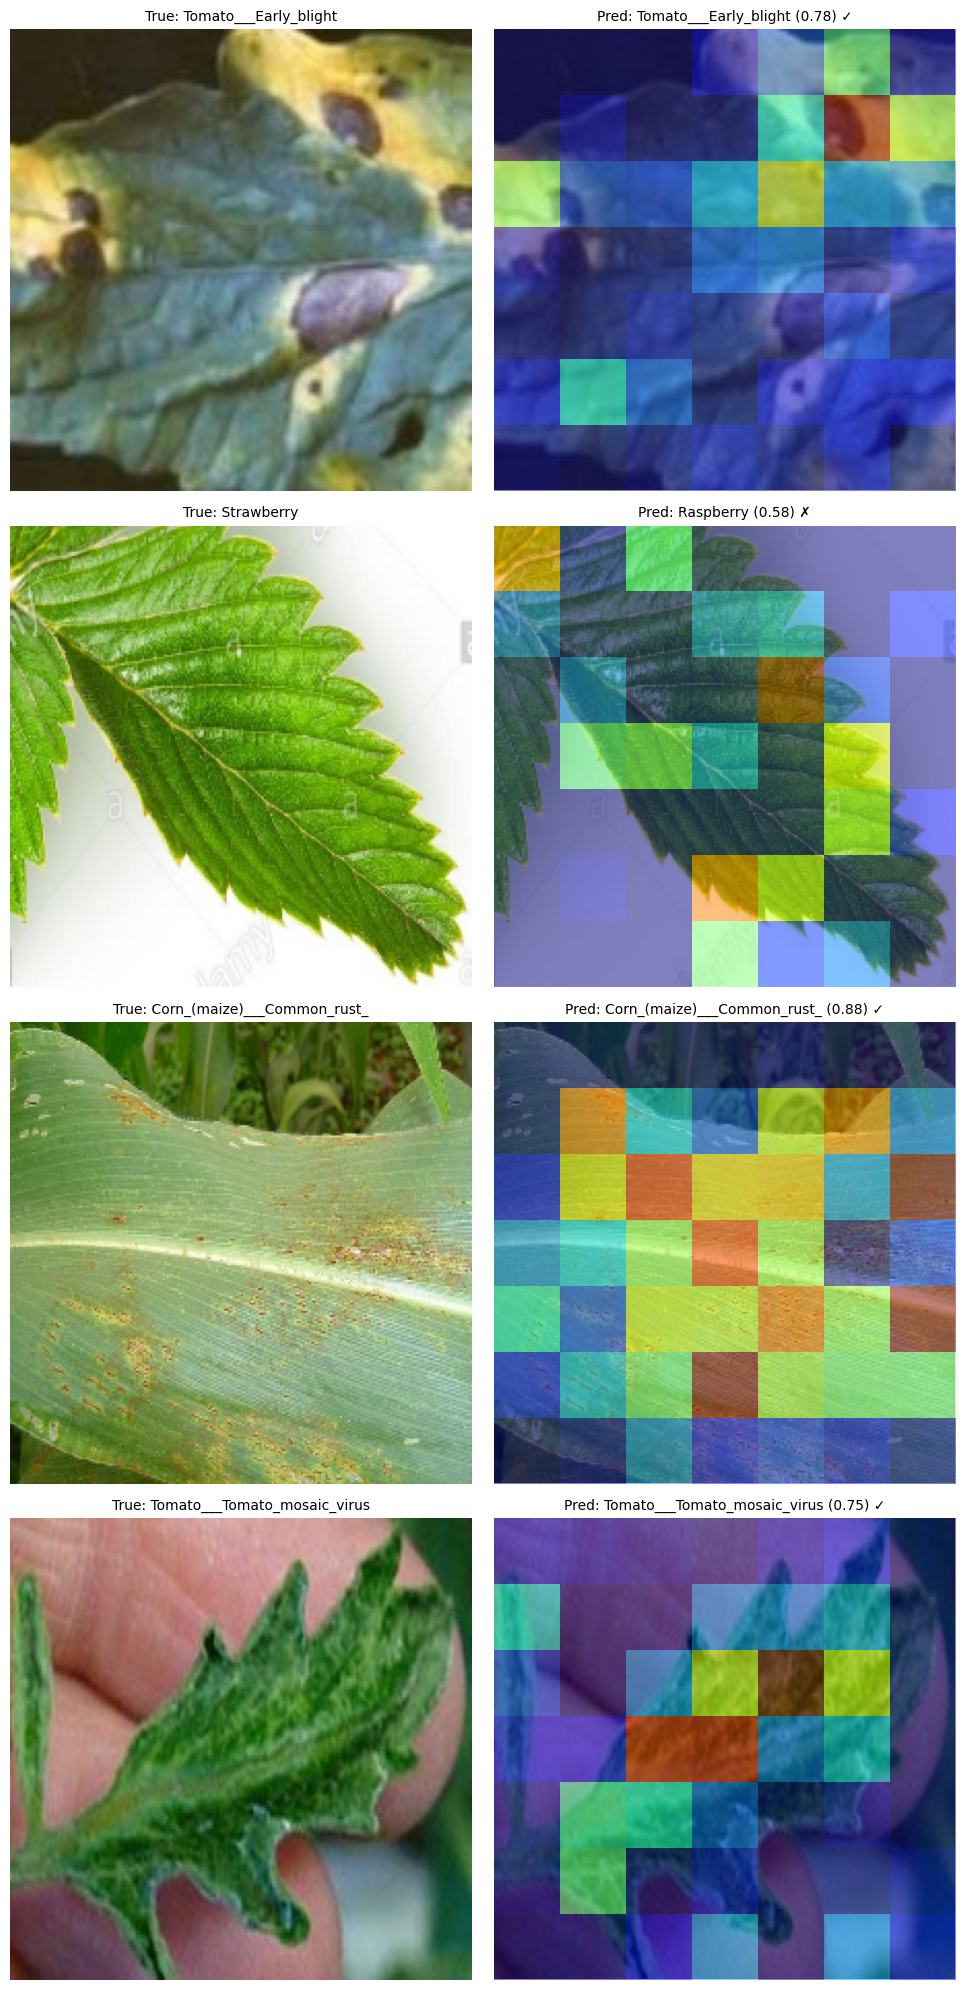

In [84]:
import matplotlib.pyplot as plt
import tensorflow as tf

sample_classes_for_gradcam = [
    "Tomato___Early_blight",       # strong performance (F1 0.58)
    "Strawberry",                   # strongest species-only class (F1 0.91)
    "Corn_(maize)___Common_rust_",  # strong disease class (F1 0.78)
    "Tomato___Tomato_mosaic_virus", # weak but improving class (F1 0.24->0.40)
]

fig, axes = plt.subplots(len(sample_classes_for_gradcam), 2, figsize=(10, 5 * len(sample_classes_for_gradcam)))

for i, cls in enumerate(sample_classes_for_gradcam):
    row = plantdoc_test_df[plantdoc_test_df["target_class"] == cls].iloc[0]
    img = tf.io.read_file(row["extracted_path"])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img_array = tf.expand_dims(img, 0)

    heatmap, pred_idx, confidence = make_gradcam_heatmap(
        img_array, model, "MobileNetV3Small", "activation_17"
    )

    axes[i, 0].imshow(img.numpy().astype("uint8"))
    axes[i, 0].set_title(f"True: {cls}", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img.numpy().astype("uint8"))
    axes[i, 1].imshow(heatmap, cmap="jet", alpha=0.5, extent=(0, IMG_SIZE[1], IMG_SIZE[0], 0))
    correct = "✓" if target_classes[pred_idx] == cls else "✗"
    axes[i, 1].set_title(f"Pred: {target_classes[pred_idx]} ({confidence:.2f}) {correct}", fontsize=10)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PlantInsight/gradcam_representative_samples.png", dpi=150)
plt.show()

In [85]:
with open("/content/drive/MyDrive/PlantInsight/gradcam_findings.txt", "w") as f:
    f.write("Grad-CAM representative samples findings:\n\n")
    f.write("1. Tomato_Early_blight: correct (0.78), heatmap focuses on lesion.\n")
    f.write("2. Strawberry -> misclassified as Raspberry (0.58). Source image had a\n")
    f.write("   watermark/stock-photo studio background; heatmap was diffuse, not\n")
    f.write("   focused - consistent with a data-quality outlier, not a systematic\n")
    f.write("   species confusion (Strawberry's overall F1 is 0.91).\n")
    f.write("3. Corn_Common_rust: correct (0.88), heatmap tightly focused on the\n")
    f.write("   rust pustules themselves.\n")
    f.write("4. Tomato_mosaic_virus: correct (0.75) - direct evidence that the\n")
    f.write("   targeted augmentation experiment improved real predictions, not\n")
    f.write("   just the aggregate metric.\n")
print("Saved: gradcam_findings.txt")

Saved: gradcam_findings.txt


In [86]:
import os
for f in ["gradcam_test_single.png", "gradcam_bacterial_spot_diagnosis.png",
          "bacterial_spot_all_test_samples.png", "gradcam_representative_samples.png",
          "gradcam_findings.txt"]:
    path = f"/content/drive/MyDrive/PlantInsight/{f}"
    print(f, "->", os.path.exists(path))

gradcam_test_single.png -> True
gradcam_bacterial_spot_diagnosis.png -> True
bacterial_spot_all_test_samples.png -> True
gradcam_representative_samples.png -> True
gradcam_findings.txt -> True


## TFLite Export and Quantization

In [87]:
print(plantdoc_test_df.columns.tolist())

['source_image', 'source_image_id', 'bbox_id', 'source_class', 'target_class', 'crop_path', 'official_split', 'width', 'height', 'min_dim']


In [88]:
import ntpath
import os

plantdoc_test_df = plantdoc_df[plantdoc_df["official_split"] == "test"].copy()

def crop_path_to_extracted_path(row):
    class_folder = row["target_class"].replace(",", "")
    filename = ntpath.basename(row["crop_path"])
    return f"/content/plantdoc_test/test/{class_folder}/{filename}"

plantdoc_test_df["extracted_path"] = plantdoc_test_df.apply(crop_path_to_extracted_path, axis=1)

assert os.path.exists(plantdoc_test_df.iloc[0]["extracted_path"]), "Path check failed - is plantdoc_test.zip extracted this session?"
print("Path check passed:", len(plantdoc_test_df), "rows ready.")

Path check passed: 384 rows ready.


In [89]:
sample_indices = np.random.RandomState(42).choice(len(plantdoc_test_df), size=30, replace=False)
keras_preds = []
tflite_preds = []

for idx in sample_indices:
    row = plantdoc_test_df.iloc[idx]
    img = tf.io.read_file(row["extracted_path"])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img_array = tf.expand_dims(img, 0)

    keras_pred = model.predict(img_array, verbose=0)
    keras_preds.append(np.argmax(keras_pred[0]))

    interpreter.set_tensor(input_details[0]['index'], img_array.numpy().astype(np.float32))
    interpreter.invoke()
    tflite_pred = interpreter.get_tensor(output_details[0]['index'])
    tflite_preds.append(np.argmax(tflite_pred[0]))

agreement = np.mean(np.array(keras_preds) == np.array(tflite_preds))
print(f"Keras vs Float32-TFLite prediction agreement: {agreement:.4f} (expect 1.0 or very close)")

Keras vs Float32-TFLite prediction agreement: 1.0000 (expect 1.0 or very close)


### Full-Integer (INT8) Quantization

Attempted first since it offers the largest size reduction.

In [90]:
def representative_dataset():
    sample_paths = pv_train_df["full_path"].sample(200, random_state=42).values
    for path in sample_paths:
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE, method="bilinear")
        img = tf.expand_dims(img, 0)
        yield [tf.cast(img, tf.float32)]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

try:
    tflite_int8_model = converter_int8.convert()
    int8_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_int8.tflite"
    with open(int8_path, "wb") as f:
        f.write(tflite_int8_model)
    int8_size_mb = os.path.getsize(int8_path) / (1024 * 1024)
    print(f"INT8 TFLite model saved: {int8_size_mb:.2f} MB (was {float32_size_mb:.2f} MB float32)")
except Exception as e:
    print("INT8 conversion failed:")
    print(type(e).__name__, str(e)[:500])

Saved artifact at '/tmp/tmp5b5cxrs_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 34), dtype=tf.float32, name=None)
Captures:
  134233706869008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706868816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706868624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TFLite model saved: 1.18 MB (was 3.63 MB float32)


**Result:** conversion succeeded, but the model failed to load at inference time (`XNNPACK` delegate could not prepare it), most likely due to MobileNetV3's squeeze-and-excitation blocks not being fully INT8-compatible. This was not forced further; falling back to a less aggressive quantization scheme.

### Dynamic-Range Quantization

Quantizes only the weights (activations remain float32), which is more broadly compatible and was verified to load and run correctly.

In [91]:
import os

converter_dynamic = tf.lite.TFLiteConverter.from_keras_model(model)
converter_dynamic.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dynamic_model = converter_dynamic.convert()

dynamic_path = "/content/drive/MyDrive/PlantInsight/mobilenetv3small_dynamic.tflite"
with open(dynamic_path, "wb") as f:
    f.write(tflite_dynamic_model)

dynamic_size_mb = os.path.getsize(dynamic_path) / (1024 * 1024)
print(f"Dynamic range TFLite model saved: {dynamic_size_mb:.2f} MB (float32 was {float32_size_mb:.2f} MB)")

interpreter_dynamic = tf.lite.Interpreter(model_path=dynamic_path)
interpreter_dynamic.allocate_tensors()
input_details_dynamic = interpreter_dynamic.get_input_details()
output_details_dynamic = interpreter_dynamic.get_output_details()

print("SUCCESS: dynamic range interpreter allocated")
print("Input details:", input_details_dynamic[0]['shape'], input_details_dynamic[0]['dtype'])
print("Output details:", output_details_dynamic[0]['shape'], output_details_dynamic[0]['dtype'])

Saved artifact at '/tmp/tmpxxi29ttq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 34), dtype=tf.float32, name=None)
Captures:
  134233706869008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706868816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706869200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706868624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233706870

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [92]:
evaluated_classes = sorted(plantdoc_test_df["target_class"].unique())
evaluated_indices = [class_to_idx[c] for c in evaluated_classes]
print(f"Evaluated classes: {len(evaluated_classes)}")

Evaluated classes: 23


In [93]:
import numpy as np
from sklearn.metrics import f1_score

y_true_dynamic = []
y_pred_dynamic = []

for idx in range(len(plantdoc_test_df)):
    row = plantdoc_test_df.iloc[idx]
    img = tf.io.read_file(row["extracted_path"])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    img_array = tf.expand_dims(img, 0)

    interpreter_dynamic.set_tensor(input_details_dynamic[0]['index'], img_array.numpy().astype(np.float32))
    interpreter_dynamic.invoke()
    output = interpreter_dynamic.get_tensor(output_details_dynamic[0]['index'])

    y_pred_dynamic.append(np.argmax(output[0]))
    y_true_dynamic.append(class_to_idx[row["target_class"]])

y_true_dynamic = np.array(y_true_dynamic)
y_pred_dynamic = np.array(y_pred_dynamic)

top1_dynamic = np.mean(y_true_dynamic == y_pred_dynamic)
f1_macro_dynamic = f1_score(y_true_dynamic, y_pred_dynamic, labels=evaluated_indices, average="macro", zero_division=0)

print(f"{'Metric':<15}{'Keras (float32)':>18}{'Dynamic TFLite':>16}")
print(f"{'Top-1':<15}{0.5625:>18.4f}{top1_dynamic:>16.4f}")
print(f"{'F1-Macro':<15}{0.5380:>18.4f}{f1_macro_dynamic:>16.4f}")

import json
tflite_comparison = {
    "keras_float32": {"top1": 0.5625, "f1_macro": 0.5380, "size_mb": 3.63},
    "tflite_dynamic_range": {"top1": round(float(top1_dynamic), 4), "f1_macro": round(float(f1_macro_dynamic), 4), "size_mb": round(dynamic_size_mb, 2)},
    "note": "INT8 full-integer quantization failed at inference time (XNNPack delegate could not prepare the model, likely due to MobileNetV3's squeeze-excitation blocks). Dynamic range quantization used instead: weights-only INT8, activations remain float32.",
}
with open("/content/drive/MyDrive/PlantInsight/tflite_quantization_comparison.json", "w") as f:
    json.dump(tflite_comparison, f, indent=2)
print("\nSaved: tflite_quantization_comparison.json")

Metric            Keras (float32)  Dynamic TFLite
Top-1                      0.5625          0.5469
F1-Macro                   0.5380          0.5266

Saved: tflite_quantization_comparison.json
